## Dataset Description

- We have 3 tables
    - Winter Olymics Info, Summer Olymics Info, Country Demorgaphic Info

The winter olymics and summer olympics table have common columns.
Each row in these tables represents an athelete winning a medal with associated information.
The columns are
- Year &#8594; Olympic Game Year
- City &#8594; Olympic Game City
- Sport &#8594; Sport the medal was won for
- Discipline &#8594; Category of Sport in Olympics
- Athlete &#8594; Name of medal winner
- Country &#8594; Country of medal winner
- Gender &#8594; Gender of Medal Winner
- Event &#8594; Specific competition awarding medals
- Medal &#8594; Medal amongst (Gold, Silver, Bronze) won by the athlete

The Country Demographic Table has the following columns
- Country &#8594; Full Country Name
- Code &#8594; Shorter Country Abbreviation
- Population &#8594; Population of the country
- GDP Per Capita &#8594; GDP of the country

## Functions Used

- pd.read_csv()
- df.info()
------
- Filter rows with NaN - df.isnull().any(axis=1)
------
- pd.concat([df1,df2],axis=0, keys=[value1,value2], names=[name1])
- df.reset_index()
- df.drop(axis=0)
------
- df.head()
- df.sample()
- df.merge(df2, how="inner", left_on="columnA", right_on="columnB")
- df.rename(columns={"original_name1":"new_name1", "original_name2":"new_name2"}, inplace=True)
- Masking One Column for Nulls - df[df[col1].isnull()]
------
- Filtering Index - df[df["Name"].str.contains("San")].index.tolist()
- Filtering and Counting Distinct columns - df[df["col1"].isnull()]["col2"].value_counts()
------
- pd.Series(index = index1, name = "name", data = list1)
- df["col1"].map(series_with_col1_index) - use --> df["country"].fillna(df["code"].map(series_with_code_index), inplace=True)
- df.dropna(subset=["col1"], inplace=True)
- df.reset_index(drop=True, inplace=True)
- df["col1"].nunique(), df.nunique()
------
- df["category_col1"].astype("category")
- df["category_col1"].cat.set_categories(["cat1", "cat2", "cat3", "cat4"], ordered=True)
------
- df["col1"].value_counts()
- df["col1"].value_counts().head(10)
- Filtering using list/index.. - df[df["col1"].isin(list1)]
------
- **Plotting**
- plt.title()
- plt.ylabel()
- series.plot(kind="bar", figsize=(12,8))
- plt.show()
- plt.figure(figsize=(10,8))
- sns.set(font_scale=1.6, palette="dark")
- sns.countplot(data=df, x="col1", order=top_10_list_ascending)
- sns.countplot(data=df, x="col1", order=top_10_list_ascending, **hue="col2"**)
- sns.countplot(data=df, x="col2", order=index1, hue="col1",hue_order = ["value1", "value2", "value3"], palette = ["gold", "silver", "brown"])
------
- pd.crosstab(index="col1", columns="col2") ⬇️
- ct__ = pd.crosstab(index="col1_with_finite_values", columns="col2_with_finite_values", margins=True, margins_name="label_eg___'total'")
- ct__.drop("Total", axis=0, inplace=True)
- Rearranging columns and Sorting - ct__[["Total", "col2", "col3", "col1"]].sort_values(by="Total", ascending=False)
- df["new_col"] = **df.apply**(lambda each: str(each["col1"])+" "+each["col3"], axis=1)
- df.groupby("col1").apply(lambda x:x["col2"].nunqiue())
- df.rank() -> method = dense, average, min, max, first

# Objectives
- #### Data Cleaning
    - Renaming Columns, Filling Missing Values, Converting Data Types
- #### Finding most successful countries in olymics; ALL TIME. Plotting using seaborn.
    - Dissecting by Medal, by Edition
- #### Finding effect of GDP and Population on Medal Tally
- #### Statistical Analysis and Hypothesis Testing
- #### Aggregating and Ranking
- #### Analysis by Gender, Region, Sport



## Observations
- ##### The top 5 countries in order of decreasing medals are: USA, Russia, UK, Germany, France
- ##### France won more medals in Summer Olympics than Germany
- ##### The top 5 countries in order of decreasing medals in _**winter olymics**_ are: USA, Canada, Sweden, Russia, Germany
- There are a total of 49 records of different olymics in the dataset. United States participated in 48 of the 49 olympics.
- The 2008 Beijing Olympics handed out the most medals at 2042.
- More games played is positively related to More medals won . There is a 0.92 spearman correlation between medals won and games participated.
- #### Statistical Analysis
    - There is a significant (positive) relationship between Total Medals and Population
    - There is a significant (positive) relationship between Total Medals and GDP per Capita
    - There is a significant (positive) relationship between Total Medals and Participations
- We created heatmaps to identify trend in medals won: by Gender, by Edition
- Brazil came 70 ranks highr in Winter Olymics than Summer Olympics. This is the maximum difference noted.
- Czech Republic came 30 ranks higher in Summer Olympics than Winter Olympics. This is the maximum difference noted.


### Conclusions
- Data is cleaned and insights developed were targeted. Dataset was analysable.

In [1]:
import pandas as pd
summer = pd.read_csv('summer.csv')
winter = pd.read_csv("winter.csv")
dic = pd.read_csv("dictionary.csv")

In [2]:
summer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31165 entries, 0 to 31164
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Year        31165 non-null  int64 
 1   City        31165 non-null  object
 2   Sport       31165 non-null  object
 3   Discipline  31165 non-null  object
 4   Athlete     31165 non-null  object
 5   Country     31161 non-null  object
 6   Gender      31165 non-null  object
 7   Event       31165 non-null  object
 8   Medal       31165 non-null  object
dtypes: int64(1), object(8)
memory usage: 2.1+ MB


In [3]:
winter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5770 entries, 0 to 5769
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Year        5770 non-null   int64 
 1   City        5770 non-null   object
 2   Sport       5770 non-null   object
 3   Discipline  5770 non-null   object
 4   Athlete     5770 non-null   object
 5   Country     5770 non-null   object
 6   Gender      5770 non-null   object
 7   Event       5770 non-null   object
 8   Medal       5770 non-null   object
dtypes: int64(1), object(8)
memory usage: 405.8+ KB


In [4]:
dic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         201 non-null    object 
 1   Code            201 non-null    object 
 2   Population      196 non-null    float64
 3   GDP per Capita  176 non-null    float64
dtypes: float64(2), object(2)
memory usage: 6.4+ KB


In [5]:
dic[dic.isnull().any(axis = 1)]

,Country,Code,Population,GDP per Capita
3,American Samoa*,ASA,55538.0,NaN
4,Andorra,AND,70473.0,NaN
9,Aruba*,ARU,103889.0,NaN
20,Bermuda*,BER,65235.0,NaN
27,British Virgin Islands,IVB,30117.0,NaN
36,Cayman Islands*,CAY,59967.0,NaN
45,Cook Islands,COK,NaN,NaN
49,Cuba,CUB,11389562.0,NaN
61,Eritrea,ERI,NaN,NaN
74,Guam,GUM,169885.0,NaN


In [6]:
olympics = pd.concat([summer, winter], axis =0, keys=["Summer", "Winter"],
         names=["Edition"]).reset_index().drop(columns = "level_1")
olympics

,Edition,Year,City,Sport,Discipline,Athlete,Country,Gender,Event,Medal
0,Summer,1896,Athens,Aquatics,Swimming,"HAJOS, Alfred",HUN,Men,100M Freestyle,Gold
1,Summer,1896,Athens,Aquatics,Swimming,"HERSCHMANN, Otto",AUT,Men,100M Freestyle,Silver
2,Summer,1896,Athens,Aquatics,Swimming,"DRIVAS, Dimitrios",GRE,Men,100M Freestyle For Sailors,Bronze
3,Summer,1896,Athens,Aquatics,Swimming,"MALOKINIS, Ioannis",GRE,Men,100M Freestyle For Sailors,Gold
4,Summer,1896,Athens,Aquatics,Swimming,"CHASAPIS, Spiridon",GRE,Men,100M Freestyle For Sailors,Silver
...,...,...,...,...,...,...,...,...,...,...
36930,Winter,2014,Sochi,Skiing,Snowboard,"JONES, Jenny",GBR,Women,Slopestyle,Bronze
36931,Winter,2014,Sochi,Skiing,Snowboard,"ANDERSON, Jamie",USA,Women,Slopestyle,Gold
36932,Winter,2014,Sochi,Skiing,Snowboard,"MALTAIS, Dominique",CAN,Women,Snowboard Cross,Silver
36933,Winter,2014,Sochi,Skiing,Snowboard,"SAMKOVA, Eva",CZE,Women,Snowboard Cross,Gold


In [7]:
olympics = olympics.merge(dic.iloc[:, :2], how ="left", left_on="Country", right_on="Code").drop(columns= ["Code"])
olympics

,Edition,Year,City,Sport,Discipline,Athlete,Country_x,Gender,Event,Medal,Country_y
0,Summer,1896,Athens,Aquatics,Swimming,"HAJOS, Alfred",HUN,Men,100M Freestyle,Gold,Hungary
1,Summer,1896,Athens,Aquatics,Swimming,"HERSCHMANN, Otto",AUT,Men,100M Freestyle,Silver,Austria
2,Summer,1896,Athens,Aquatics,Swimming,"DRIVAS, Dimitrios",GRE,Men,100M Freestyle For Sailors,Bronze,Greece
3,Summer,1896,Athens,Aquatics,Swimming,"MALOKINIS, Ioannis",GRE,Men,100M Freestyle For Sailors,Gold,Greece
4,Summer,1896,Athens,Aquatics,Swimming,"CHASAPIS, Spiridon",GRE,Men,100M Freestyle For Sailors,Silver,Greece
...,...,...,...,...,...,...,...,...,...,...,...
36930,Winter,2014,Sochi,Skiing,Snowboard,"JONES, Jenny",GBR,Women,Slopestyle,Bronze,United Kingdom
36931,Winter,2014,Sochi,Skiing,Snowboard,"ANDERSON, Jamie",USA,Women,Slopestyle,Gold,United States
36932,Winter,2014,Sochi,Skiing,Snowboard,"MALTAIS, Dominique",CAN,Women,Snowboard Cross,Silver,Canada
36933,Winter,2014,Sochi,Skiing,Snowboard,"SAMKOVA, Eva",CZE,Women,Snowboard Cross,Gold,Czech Republic


In [8]:
olympics.rename(columns={"Country_x": "Code", "Country_y": "Country"}, inplace = True)

In [9]:
dic.rename(columns= {"GDP per Capita": "GPD"}, inplace = True)

In [10]:
olympics.loc[olympics["Country"].isnull()]

,Edition,Year,City,Sport,Discipline,Athlete,Code,Gender,Event,Medal,Country
132,Summer,1896,Athens,Tennis,Tennis,"FLACK, Edwin",ZZX,Men,Doubles,Bronze,NaN
133,Summer,1896,Athens,Tennis,Tennis,"ROBERTSON, George Stuart",ZZX,Men,Doubles,Bronze,NaN
134,Summer,1896,Athens,Tennis,Tennis,"BOLAND, John",ZZX,Men,Doubles,Gold,NaN
135,Summer,1896,Athens,Tennis,Tennis,"TRAUN, Friedrich",ZZX,Men,Doubles,Gold,NaN
136,Summer,1896,Athens,Tennis,Tennis,"KASDAGLIS, Dionysios",ZZX,Men,Doubles,Silver,NaN
...,...,...,...,...,...,...,...,...,...,...,...
33961,Winter,1992,Albertville,Skiing,Freestyle Skiing,"KOZHEVNIKOVA, Yelizaveta",EUN,Women,Moguls,Silver,NaN
33977,Winter,1992,Albertville,Skiing,Ski Jumping,"GODER, Tomas",TCH,Men,K120 Team (90M),Bronze,NaN
33978,Winter,1992,Albertville,Skiing,Ski Jumping,"JEZ, Frantisek",TCH,Men,K120 Team (90M),Bronze,NaN
33979,Winter,1992,Albertville,Skiing,Ski Jumping,"PARMA, Jiri",TCH,Men,K120 Team (90M),Bronze,NaN


In [11]:
missing_C_index = olympics.loc[olympics["Country"].isnull()].index
missing_C_index

Index([  132,   133,   134,   135,   136,   137,   257,   258,   259,   260,
       ...
       33939, 33947, 33949, 33953, 33954, 33961, 33977, 33978, 33979, 33980],
      dtype='int64', length=6367)

In [12]:
olympics.loc[olympics["Country"].isnull()]["Code"].value_counts()

Code
URS    2489
GDR     987
ROU     642
FRG     584
TCH     487
YUG     442
EUN     283
EUA     281
ZZX      48
SRB      31
ANZ      29
RU1      17
MNE      14
TTO      10
BOH       7
BWI       5
SGP       4
IOP       3
Name: count, dtype: int64

In [13]:
old_c = olympics.loc[olympics["Country"].isnull(), :]["Code"].value_counts().index
old_c

Index(['URS', 'GDR', 'ROU', 'FRG', 'TCH', 'YUG', 'EUN', 'EUA', 'ZZX', 'SRB',
       'ANZ', 'RU1', 'MNE', 'TTO', 'BOH', 'BWI', 'SGP', 'IOP'],
      dtype='object', name='Code')

In [14]:
mapper = pd.Series(index=old_c, name = "Country", data = ["Soviet Union", "East Germany", "Romania", "West Germany", "Czechoslovakia",
                               "Yugoslavia", "Unified Team", "Unified Team of Germany", "Mixed teams", "Serbia",
                              "Australasia", "Russian Empire", "Montenegro", "Trinidad and Tobago", "Bohemia", 
                              "West Indies Federation", "Singapore", "Independent Olympic Participants"])

In [15]:
olympics.loc[missing_C_index, "Code"].map(mapper)

132         Mixed teams
133         Mixed teams
134         Mixed teams
135         Mixed teams
136         Mixed teams
              ...      
33961      Unified Team
33977    Czechoslovakia
33978    Czechoslovakia
33979    Czechoslovakia
33980    Czechoslovakia
Name: Code, Length: 6367, dtype: object

In [16]:
olympics["Country"].fillna(olympics["Code"].map(mapper), inplace = True)

In [17]:
olympics.loc[missing_C_index]

,Edition,Year,City,Sport,Discipline,Athlete,Code,Gender,Event,Medal,Country
132,Summer,1896,Athens,Tennis,Tennis,"FLACK, Edwin",ZZX,Men,Doubles,Bronze,Mixed teams
133,Summer,1896,Athens,Tennis,Tennis,"ROBERTSON, George Stuart",ZZX,Men,Doubles,Bronze,Mixed teams
134,Summer,1896,Athens,Tennis,Tennis,"BOLAND, John",ZZX,Men,Doubles,Gold,Mixed teams
135,Summer,1896,Athens,Tennis,Tennis,"TRAUN, Friedrich",ZZX,Men,Doubles,Gold,Mixed teams
136,Summer,1896,Athens,Tennis,Tennis,"KASDAGLIS, Dionysios",ZZX,Men,Doubles,Silver,Mixed teams
...,...,...,...,...,...,...,...,...,...,...,...
33961,Winter,1992,Albertville,Skiing,Freestyle Skiing,"KOZHEVNIKOVA, Yelizaveta",EUN,Women,Moguls,Silver,Unified Team
33977,Winter,1992,Albertville,Skiing,Ski Jumping,"GODER, Tomas",TCH,Men,K120 Team (90M),Bronze,Czechoslovakia
33978,Winter,1992,Albertville,Skiing,Ski Jumping,"JEZ, Frantisek",TCH,Men,K120 Team (90M),Bronze,Czechoslovakia
33979,Winter,1992,Albertville,Skiing,Ski Jumping,"PARMA, Jiri",TCH,Men,K120 Team (90M),Bronze,Czechoslovakia


In [18]:
olympics.dropna(subset=["Code"], inplace = True)

In [19]:
olympics.reset_index(drop= True, inplace= True)

In [20]:
olympics.nunique()

Edition           2
Year             33
City             41
Sport            48
Discipline       80
Athlete       26494
Code            148
Gender            2
Event           733
Medal             3
Country         145
dtype: int64

In [21]:
olympics["Medal"] = olympics["Medal"].astype("category")
olympics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36931 entries, 0 to 36930
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Edition     36931 non-null  object  
 1   Year        36931 non-null  int64   
 2   City        36931 non-null  object  
 3   Sport       36931 non-null  object  
 4   Discipline  36931 non-null  object  
 5   Athlete     36931 non-null  object  
 6   Code        36931 non-null  object  
 7   Gender      36931 non-null  object  
 8   Event       36931 non-null  object  
 9   Medal       36931 non-null  category
 10  Country     36931 non-null  object  
dtypes: category(1), int64(1), object(9)
memory usage: 2.9+ MB


In [22]:
olympics["Medal"].sort_values()

36930    Bronze
25565    Bronze
25562    Bronze
25559    Bronze
11084    Bronze
          ...  
10811    Silver
10810    Silver
10809    Silver
25834    Silver
18465    Silver
Name: Medal, Length: 36931, dtype: category
Categories (3, object): ['Bronze', 'Gold', 'Silver']

In [23]:
olympics["Medal"] = olympics["Medal"].cat.set_categories(["Bronze", "Silver", "Gold"], ordered = True)

In [24]:
olympics["Medal"].sort_values()

36930    Bronze
8916     Bronze
15339    Bronze
27698    Bronze
8919     Bronze
          ...  
25833      Gold
10807      Gold
10806      Gold
10804      Gold
0          Gold
Name: Medal, Length: 36931, dtype: category
Categories (3, object): ['Bronze' < 'Silver' < 'Gold']

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
top_10 = olympics["Country"].value_counts().head(10)

In [27]:
top_10

Country
United States     5238
Soviet Union      2489
United Kingdom    1799
Germany           1665
France            1548
Italy             1488
Sweden            1477
Canada            1274
Australia         1204
Hungary           1091
Name: count, dtype: int64

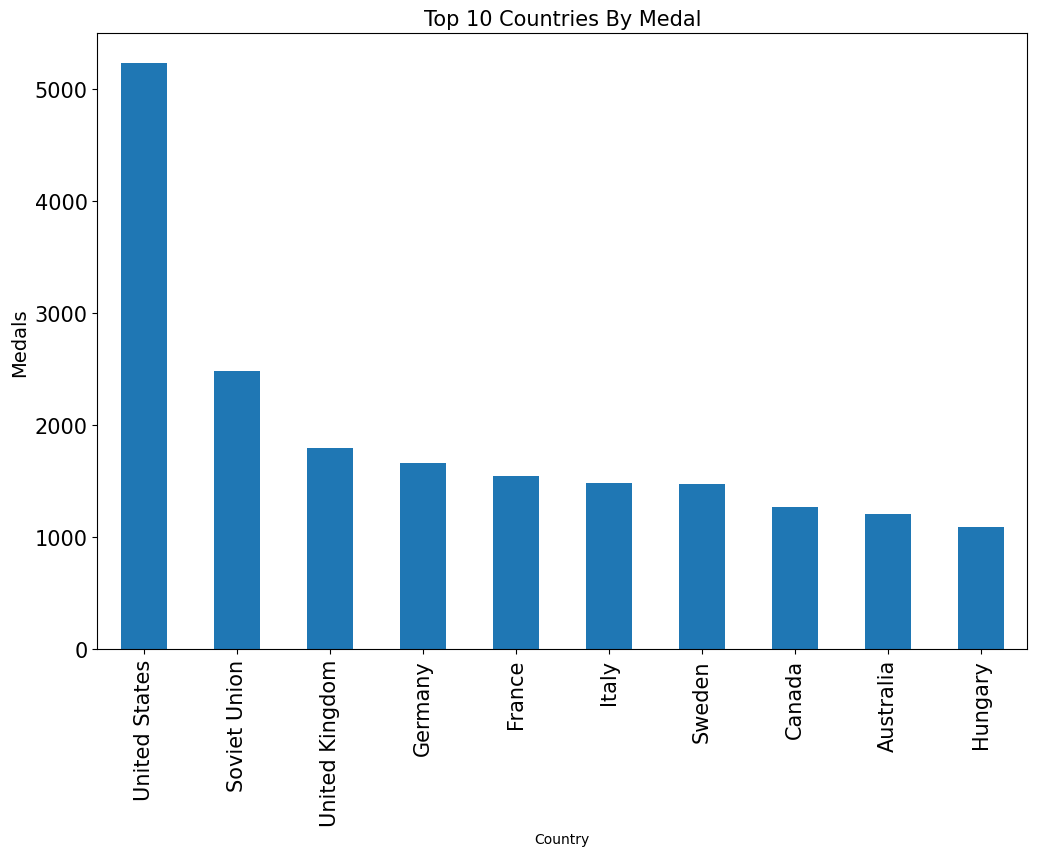

In [28]:
top_10.plot(kind = 'bar', fontsize = 15, figsize=(12,8))
plt.title("Top 10 Countries By Medal", fontsize = 15)
plt.ylabel("Medals", fontsize = 14)
plt.show()

In [29]:
olympics_10 = olympics[olympics['Country'].isin(top_10.index)]
olympics_10

,Edition,Year,City,Sport,Discipline,Athlete,Code,Gender,Event,Medal,Country
0,Summer,1896,Athens,Aquatics,Swimming,"HAJOS, Alfred",HUN,Men,100M Freestyle,Gold,Hungary
6,Summer,1896,Athens,Aquatics,Swimming,"HAJOS, Alfred",HUN,Men,1200M Freestyle,Gold,Hungary
11,Summer,1896,Athens,Athletics,Athletics,"LANE, Francis",USA,Men,100M,Bronze,United States
12,Summer,1896,Athens,Athletics,Athletics,"SZOKOLYI, Alajos",HUN,Men,100M,Bronze,Hungary
13,Summer,1896,Athens,Athletics,Athletics,"BURKE, Thomas",USA,Men,100M,Gold,United States
...,...,...,...,...,...,...,...,...,...,...,...
36924,Winter,2014,Sochi,Skiing,Snowboard,"KOBER, Amelie",GER,Women,Parallel Slalom,Bronze,Germany
36926,Winter,2014,Sochi,Skiing,Snowboard,"JONES, Jenny",GBR,Women,Slopestyle,Bronze,United Kingdom
36927,Winter,2014,Sochi,Skiing,Snowboard,"ANDERSON, Jamie",USA,Women,Slopestyle,Gold,United States
36928,Winter,2014,Sochi,Skiing,Snowboard,"MALTAIS, Dominique",CAN,Women,Snowboard Cross,Silver,Canada


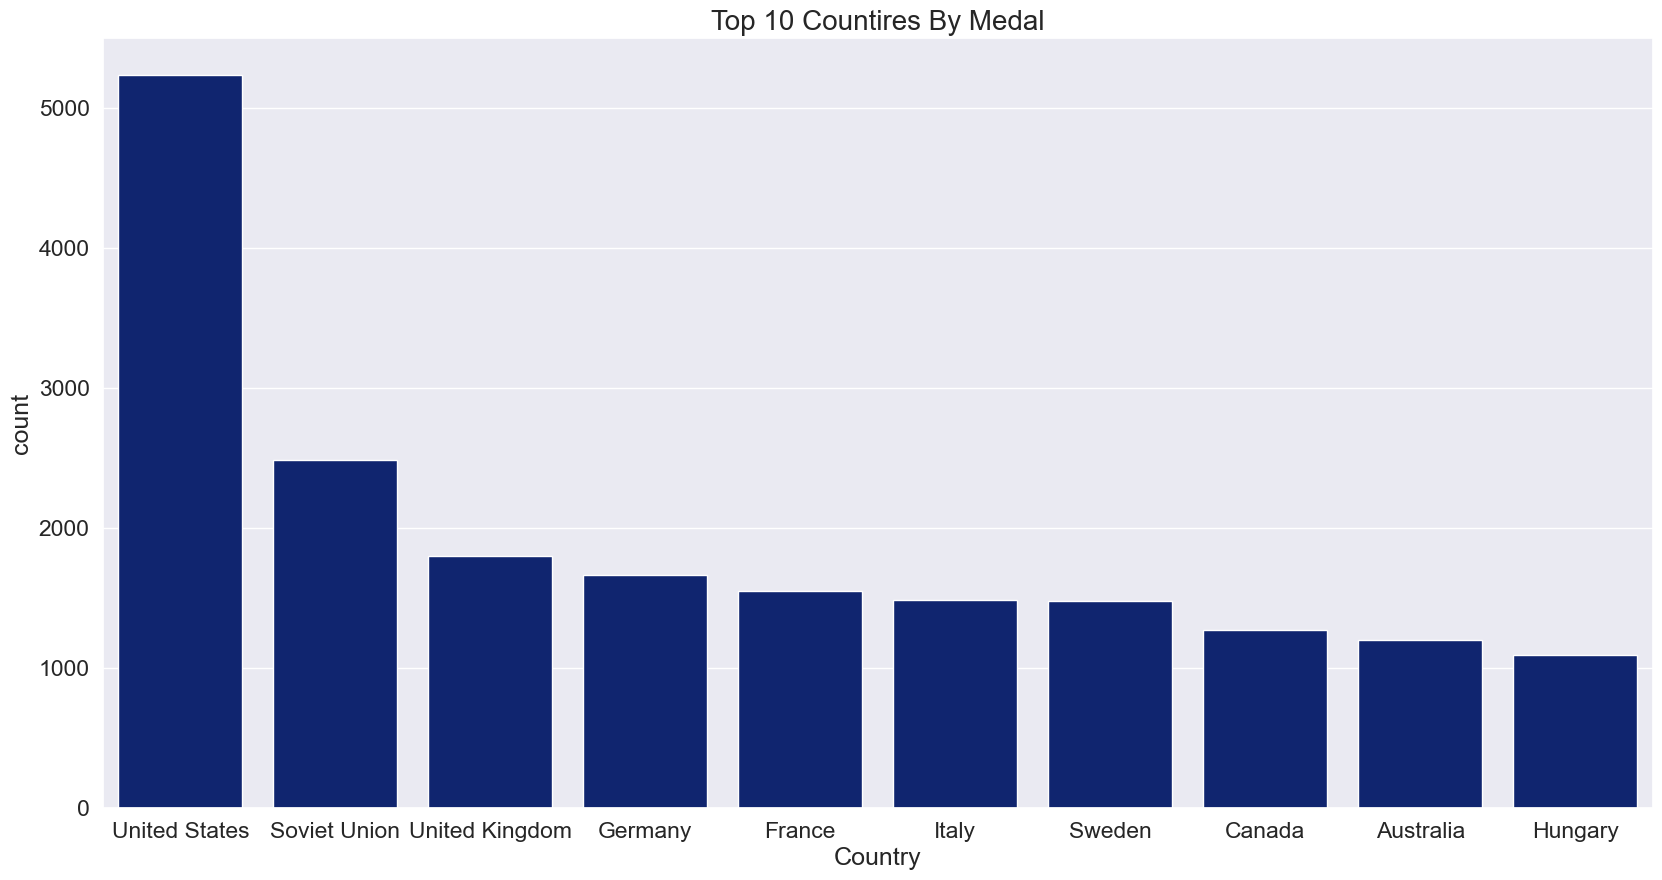

In [30]:
plt.figure(figsize=(20,10))
sns.set(font_scale = 1.5, palette = 'dark')
sns.countplot(data = olympics_10, x ="Country", order= top_10.index)
plt.title("Top 10 Countires By Medal", fontsize = 20)
plt.show()

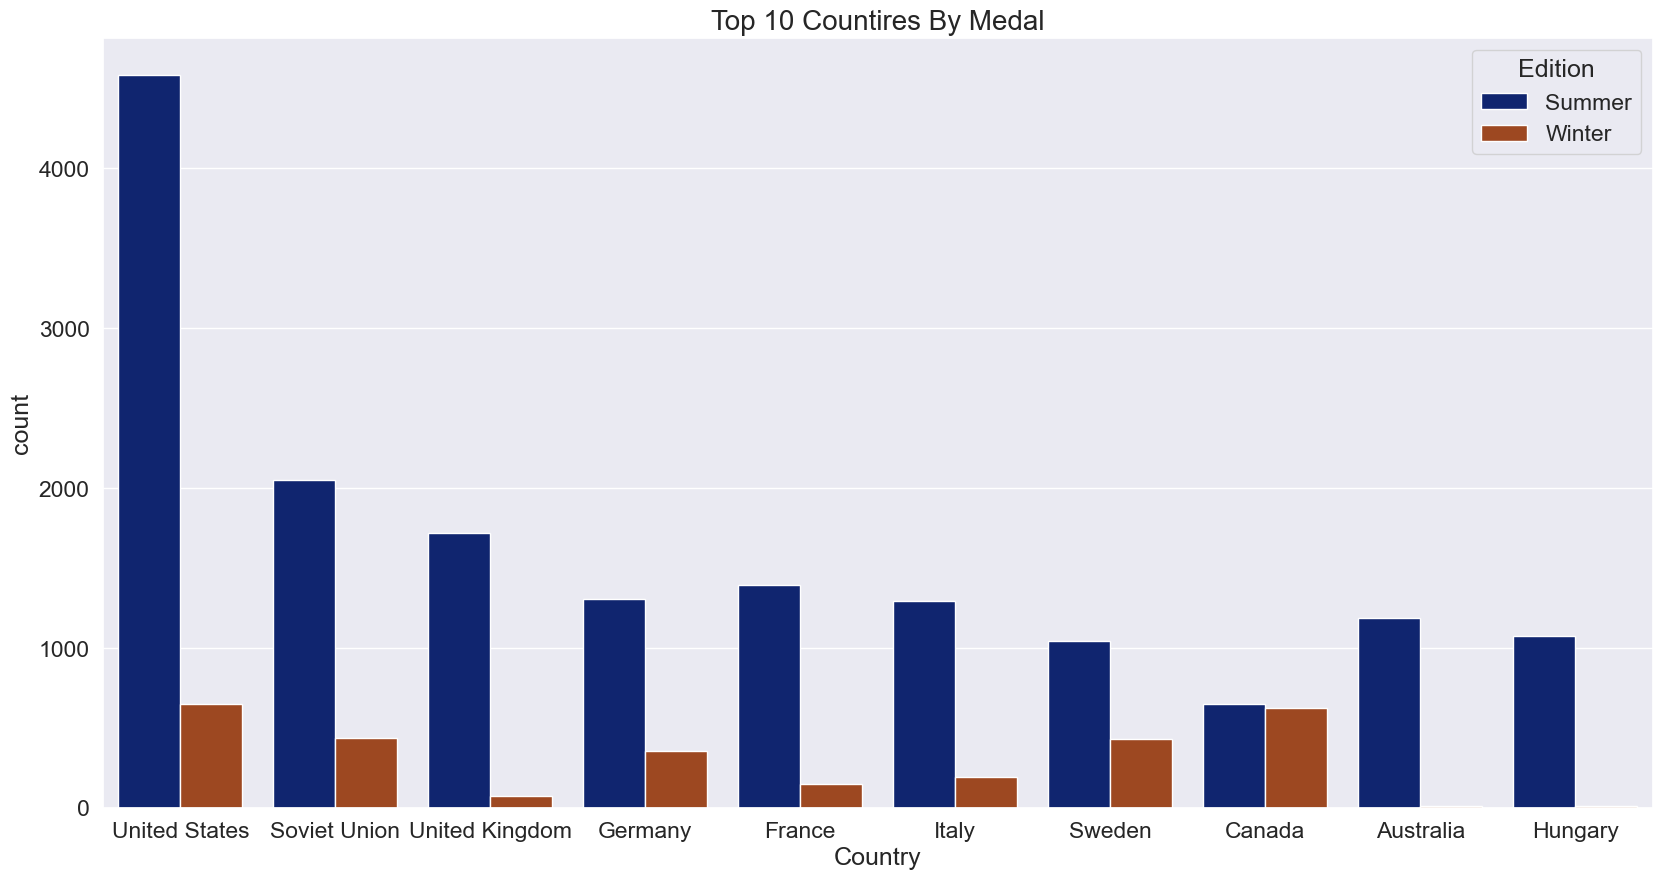

In [31]:
plt.figure(figsize=(20,10))
sns.set(font_scale = 1.5, palette = 'dark')
sns.countplot(data = olympics_10, x ="Country", hue = "Edition", order= top_10.index)
plt.title("Top 10 Countires By Medal", fontsize = 20)
plt.show()

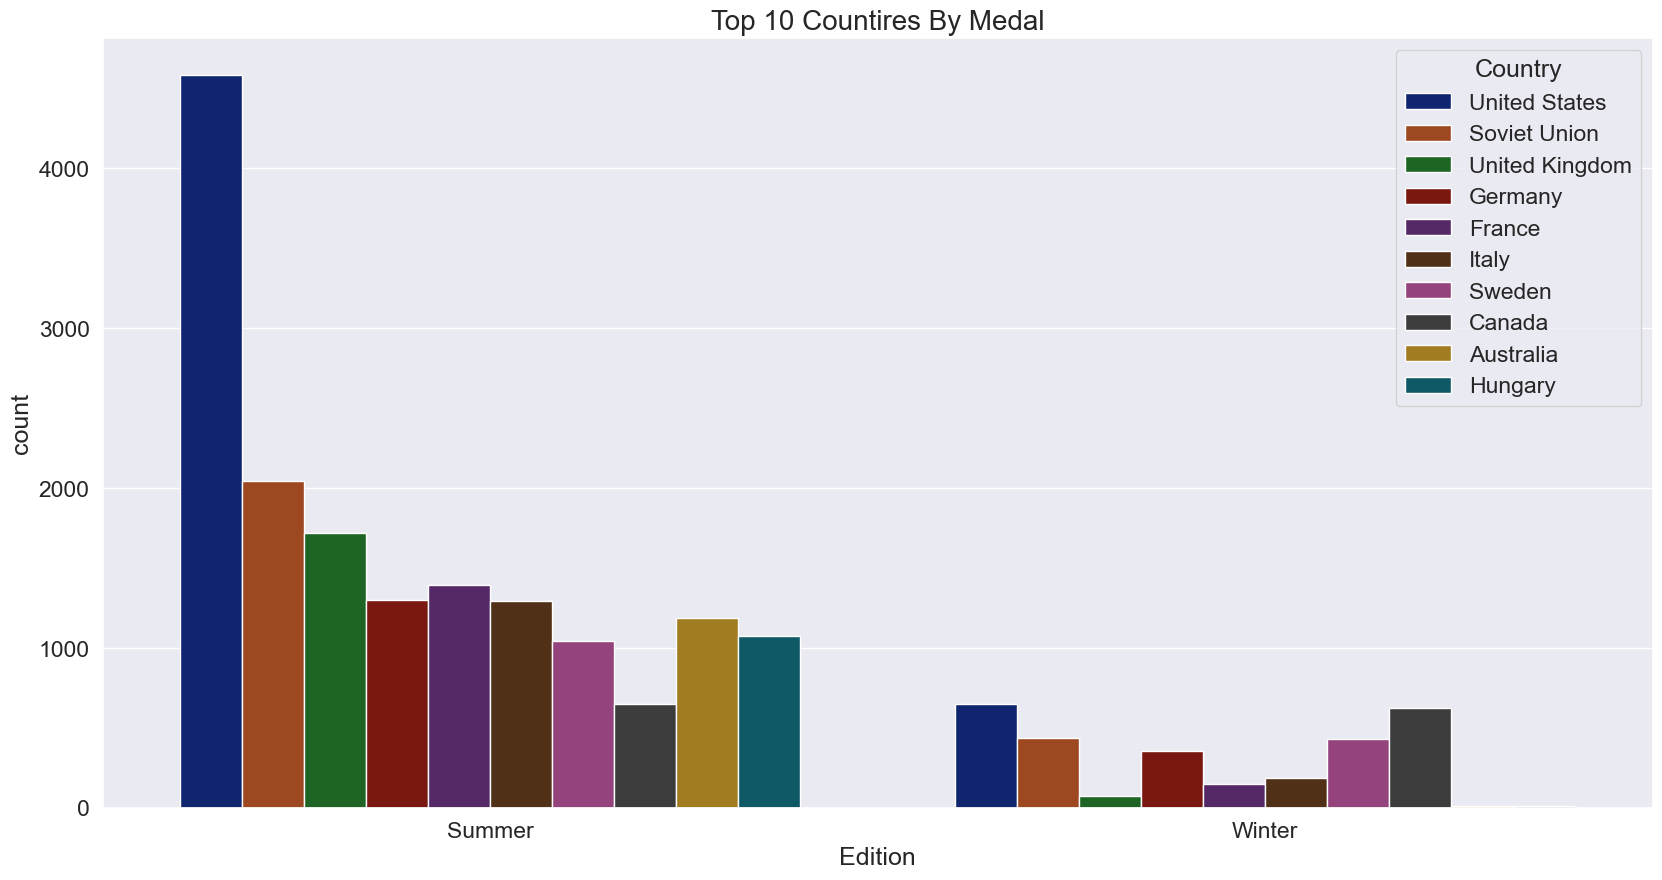

In [32]:
plt.figure(figsize=(20,10))
sns.set(font_scale = 1.5, palette = 'dark')
sns.countplot(data = olympics_10, x ="Edition", hue = "Country", hue_order= top_10.index)
plt.title("Top 10 Countires By Medal", fontsize = 20)
plt.show()

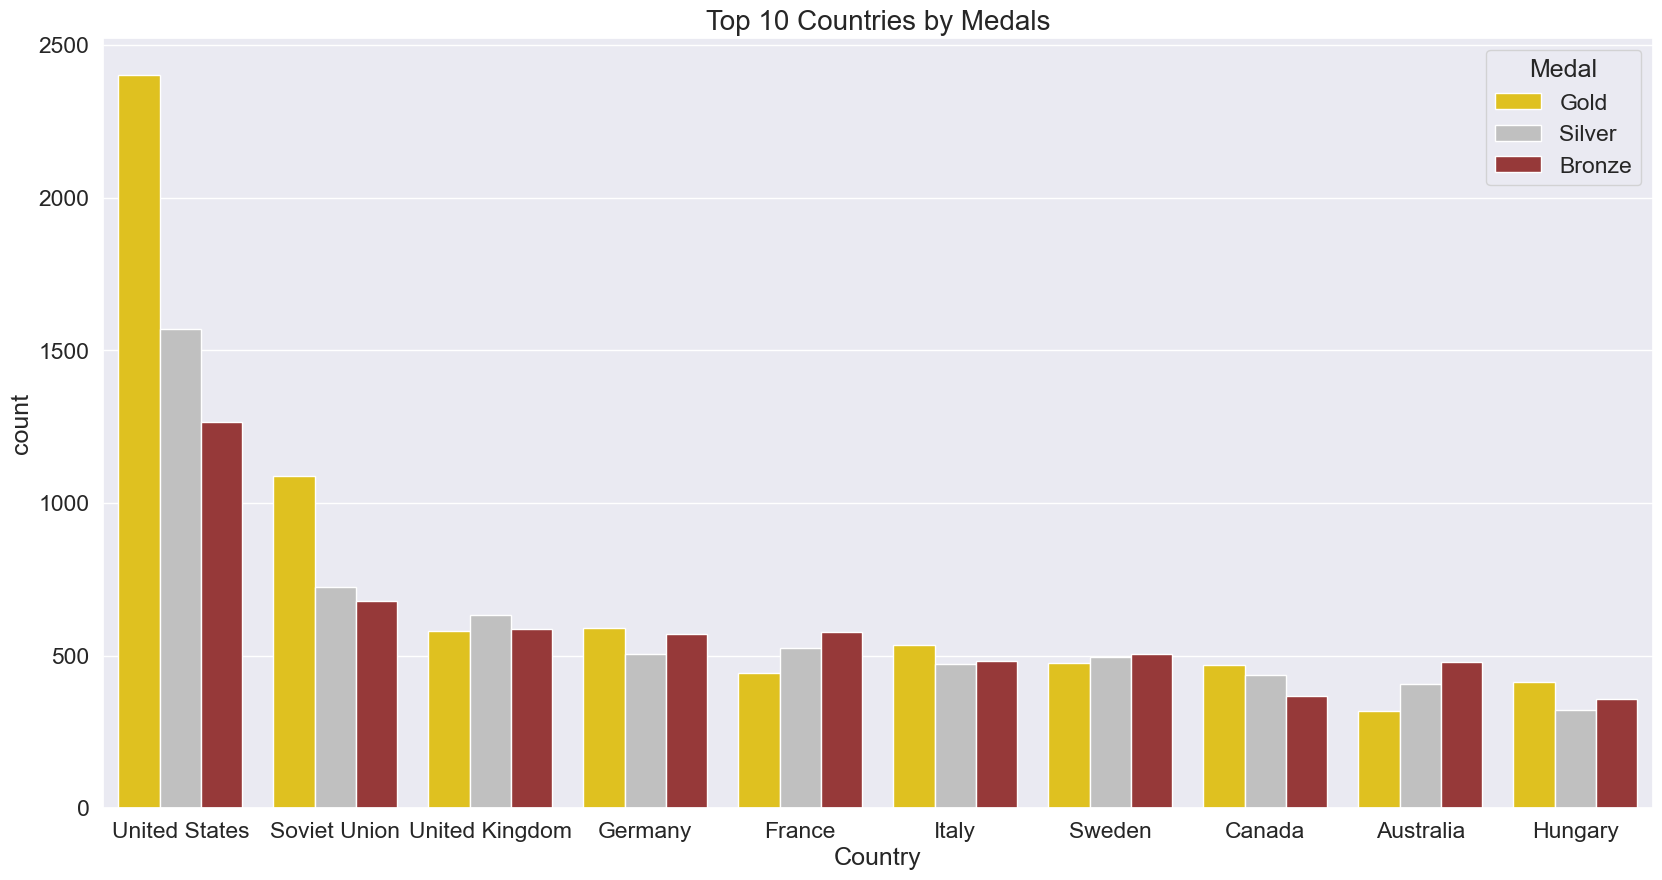

In [33]:
plt.figure(figsize=(20,10))
sns.set(font_scale=1.5, palette= "dark")
sns.countplot(data = olympics_10, x = "Country", hue = "Medal", order = top_10.index,
              hue_order = ["Gold", "Silver", "Bronze"], palette = ["gold", "silver", "brown"])
plt.title("Top 10 Countries by Medals", fontsize = 20)
plt.show()

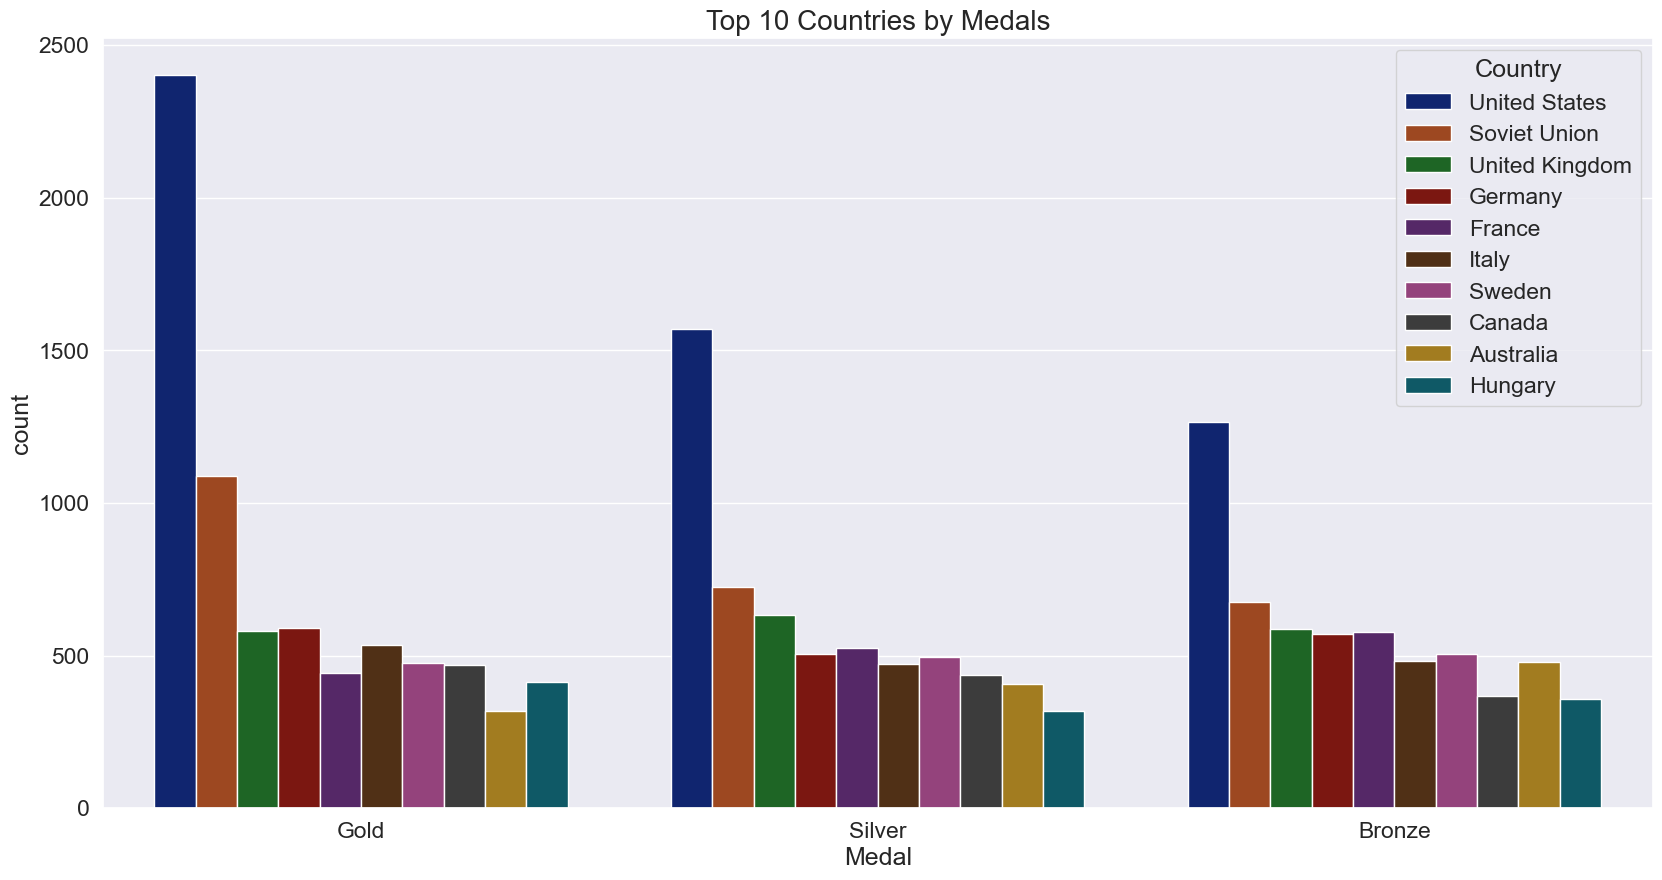

In [34]:
plt.figure(figsize=(20,10))
sns.set(font_scale=1.5, palette= "dark")
sns.countplot(data = olympics_10, x = "Medal", hue = "Country", 
              order = ["Gold", "Silver", "Bronze"], hue_order= top_10.index)
plt.title("Top 10 Countries by Medals", fontsize = 20)
plt.show()

In [35]:
medals_per_country = pd.crosstab(index= olympics["Country"], columns= olympics["Medal"],
                                margins= True, margins_name= "Total")
medals_per_country

Medal,Bronze,Silver,Gold,Total
Country,,,,
Afghanistan,2,0,0,2
Algeria,8,2,5,15
Argentina,91,99,69,259
Armenia,8,2,1,11
Australasia,5,4,20,29
...,...,...,...,...
West Indies Federation,5,0,0,5
Yugoslavia,119,180,143,442
Zambia,1,1,0,2


In [36]:
medals_per_country.drop("Total", axis= 0, inplace= True)

In [37]:
medals_per_country = medals_per_country[["Total", "Gold", "Silver", "Bronze"]].sort_values(by= ["Total"], ascending=False)

In [38]:
medals_per_country = medals_per_country.merge(dic, how='left', left_index= True,
                                             right_on= "Country").drop(columns= ['Code']).set_index("Country")
medals_per_country

,Total,Gold,Silver,Bronze,Population,GPD
Country,,,,,,
United States,5238,2402,1571,1265,321418820.0,56115.718426
Soviet Union,2489,1088,724,677,NaN,NaN
United Kingdom,1799,580,632,587,65138232.0,43875.969614
Germany,1665,589,504,572,81413145.0,41313.313995
France,1548,444,526,578,66808385.0,36205.568102
...,...,...,...,...,...,...
Iraq,1,0,0,1,36423395.0,4943.760388
Senegal,1,0,1,0,15129273.0,899.579879
Macedonia,1,0,0,1,2078453.0,4852.657848


In [39]:
olympics.nunique()

Edition           2
Year             33
City             41
Sport            48
Discipline       80
Athlete       26494
Code            148
Gender            2
Event           733
Medal             3
Country         145
dtype: int64

In [40]:
olympics['Games'] = olympics.apply(lambda x: str(x["Year"]) + " " + x["City"], axis = 1)
olympics

,Edition,Year,City,Sport,Discipline,Athlete,Code,Gender,Event,Medal,Country,Games
0,Summer,1896,Athens,Aquatics,Swimming,"HAJOS, Alfred",HUN,Men,100M Freestyle,Gold,Hungary,1896 Athens
1,Summer,1896,Athens,Aquatics,Swimming,"HERSCHMANN, Otto",AUT,Men,100M Freestyle,Silver,Austria,1896 Athens
2,Summer,1896,Athens,Aquatics,Swimming,"DRIVAS, Dimitrios",GRE,Men,100M Freestyle For Sailors,Bronze,Greece,1896 Athens
3,Summer,1896,Athens,Aquatics,Swimming,"MALOKINIS, Ioannis",GRE,Men,100M Freestyle For Sailors,Gold,Greece,1896 Athens
4,Summer,1896,Athens,Aquatics,Swimming,"CHASAPIS, Spiridon",GRE,Men,100M Freestyle For Sailors,Silver,Greece,1896 Athens
...,...,...,...,...,...,...,...,...,...,...,...,...
36926,Winter,2014,Sochi,Skiing,Snowboard,"JONES, Jenny",GBR,Women,Slopestyle,Bronze,United Kingdom,2014 Sochi
36927,Winter,2014,Sochi,Skiing,Snowboard,"ANDERSON, Jamie",USA,Women,Slopestyle,Gold,United States,2014 Sochi
36928,Winter,2014,Sochi,Skiing,Snowboard,"MALTAIS, Dominique",CAN,Women,Snowboard Cross,Silver,Canada,2014 Sochi
36929,Winter,2014,Sochi,Skiing,Snowboard,"SAMKOVA, Eva",CZE,Women,Snowboard Cross,Gold,Czech Republic,2014 Sochi


In [41]:
olympics["Games"].nunique()

49

In [42]:
olympics["Games"].value_counts()

Games
2008 Beijing                   2042
2000 Sydney                    2015
2004 Athens                    1998
2012 London                    1945
1996 Atlanta                   1859
1992 Barcelona                 1705
1988 Seoul                     1546
1984 Los Angeles               1459
1980 Moscow                    1387
1976 Montreal                  1305
1920 Antwerp                   1298
1972 Munich                    1185
1968 Mexico                    1031
1964 Tokyo                     1010
1952 Helsinki                   889
1956 Melbourne / Stockholm      885
1912 Stockholm                  885
1924 Paris                      884
1960 Rome                       882
1936 Berlin                     875
1948 London                     814
1908 London                     804
1928 Amsterdam                  710
1932 Los Angeles                615
2014 Sochi                      612
2006 Turin                      531
2010 Vancouver                  529
1900 Paris            

In [43]:
medals_per_country["Total Games"] = olympics.groupby("Country").apply(lambda x: x["Games"].nunique())
medals_per_country

/var/folders/cc/b5vn24951j99tz2k3vksmzp80000gn/T/ipykernel_93637/2355538745.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  medals_per_country["Total Games"] = olympics.groupby("Country").apply(lambda x: x["Games"].nunique())


,Total,Gold,Silver,Bronze,Population,GPD,Total Games
Country,,,,,,,
United States,5238,2402,1571,1265,321418820.0,56115.718426,48
Soviet Union,2489,1088,724,677,NaN,NaN,18
United Kingdom,1799,580,632,587,65138232.0,43875.969614,42
Germany,1665,589,504,572,81413145.0,41313.313995,25
France,1548,444,526,578,66808385.0,36205.568102,47
...,...,...,...,...,...,...,...
Iraq,1,0,0,1,36423395.0,4943.760388,1
Senegal,1,0,1,0,15129273.0,899.579879,1
Macedonia,1,0,0,1,2078453.0,4852.657848,1


In [44]:
medals_per_country.rank(ascending= False)

,Total,Gold,Silver,Bronze,Population,GPD,Total Games
Country,,,,,,,
United States,1.0,1.0,1.0,1.0,3.0,7.0,1.0
Soviet Union,2.0,2.0,2.0,2.0,NaN,NaN,28.0
United Kingdom,3.0,4.0,3.0,3.0,20.0,13.0,10.0
Germany,4.0,3.0,5.0,5.0,15.0,18.0,19.0
France,5.0,8.0,4.0,4.0,19.0,22.0,3.0
...,...,...,...,...,...,...,...
Iraq,133.5,122.5,135.0,114.5,34.0,76.0,131.0
Senegal,133.5,122.5,113.0,134.5,60.0,110.0,131.0
Macedonia,133.5,122.5,135.0,114.5,108.0,77.0,131.0


In [45]:
medals_per_country.drop(columns= ["Gold", "Silver", "Bronze"], inplace = True)

In [46]:
medals_per_country.corr(method= 'pearson')

,Total,Population,GPD,Total Games
Total,1.000000,0.206606,0.437131,0.712917
Population,0.206606,1.000000,-0.089976,0.123700
GPD,0.437131,-0.089976,1.000000,0.563540
Total Games,0.712917,0.123700,0.563540,1.000000


In [47]:
medals_per_country.corr(method= 'spearman')

,Total,Population,GPD,Total Games
Total,1.000000,0.419755,0.458478,0.927611
Population,0.419755,1.000000,-0.239097,0.402098
GPD,0.458478,-0.239097,1.000000,0.498056
Total Games,0.927611,0.402098,0.498056,1.000000


In [48]:
medals_per_country.rank(ascending=False).corr(method= 'pearson')

,Total,Population,GPD,Total Games
Total,1.000000,0.419634,0.458508,0.927611
Population,0.419634,1.000000,-0.239567,0.401448
GPD,0.458508,-0.239567,1.000000,0.497109
Total Games,0.927611,0.401448,0.497109,1.000000


Hypothesis 1: There is no relationship between Total Medals and Populat

In [49]:
import scipy.stats as stats

In [50]:
stats.spearmanr(medals_per_country["Total"], medals_per_country["Population"], nan_policy= 'omit')

SignificanceResult(statistic=np.float64(0.4197552788706392), pvalue=np.float64(8.132240868116953e-07))

In [51]:
r, p_value = stats.spearmanr(medals_per_country["Total"], medals_per_country["Population"], nan_policy= 'omit')

In [52]:
r

np.float64(0.4197552788706392)

In [53]:
p_value

np.float64(8.132240868116953e-07)

Reject Hypothesis 1 -> There is a significant (positive) relationship between Total Medals and Population

Hypothesis 2: There is no relationship between Total Medals and GDP per Capita

In [54]:
r, p_value = stats.spearmanr(medals_per_country["Total"], medals_per_country["GPD"],
                            nan_policy= "omit")

In [55]:
r

np.float64(0.45847787983426685)

In [56]:
p_value

np.float64(1.5758169913239557e-07)

Reject Hypothesis 2 -> There is a significant (positive) relationship between Total Medals and GDP per Capita

Hypothesis 3: There is no relationship between Total Medals and Participations

In [57]:
r, p_value = stats.spearmanr(medals_per_country.head(50)["Total"], medals_per_country.head(50)["Total Games"])

In [58]:
r

np.float64(0.6818689415046658)

In [59]:
p_value

np.float64(4.982151209468698e-08)

Reject Hypothesis 3 -> There is a significant (positive) relationship between Total Medals and Participations

In [61]:
sum_vs_win = pd.crosstab(olympics["Country"], olympics["Edition"])
sum_vs_win

Edition,Summer,Winter
Country,,
Afghanistan,2,0
Algeria,15,0
Argentina,259,0
Armenia,11,0
Australasia,29,0
...,...,...
West Germany,490,94
West Indies Federation,5,0
Yugoslavia,435,7


In [62]:
men_vs_women = pd.crosstab(olympics["Country"], olympics["Gender"])
men_vs_women

Gender,Men,Women
Country,,
Afghanistan,2,0
Algeria,12,3
Argentina,187,72
Armenia,11,0
Australasia,27,2
...,...,...
West Germany,450,134
West Indies Federation,5,0
Yugoslavia,379,63


In [63]:
medals_by_cats = pd.concat([sum_vs_win, men_vs_women], axis = 1)
medals_by_cats

,Summer,Winter,Men,Women
Country,,,,
Afghanistan,2,0,2,0
Algeria,15,0,12,3
Argentina,259,0,187,72
Armenia,11,0,11,0
Australasia,29,0,27,2
...,...,...,...,...
West Germany,490,94,450,134
West Indies Federation,5,0,5,0
Yugoslavia,435,7,379,63


In [64]:
medals_by_cats["Total"] = medals_by_cats["Summer"] + medals_by_cats["Winter"]
medals_by_cats

,Summer,Winter,Men,Women,Total
Country,,,,,
Afghanistan,2,0,2,0,2
Algeria,15,0,12,3,15
Argentina,259,0,187,72,259
Armenia,11,0,11,0,11
Australasia,29,0,27,2,29
...,...,...,...,...,...
West Germany,490,94,450,134,584
West Indies Federation,5,0,5,0,5
Yugoslavia,435,7,379,63,442


In [65]:
medals_by_cats.sort_values("Total", ascending = False, inplace = True)
medals_by_cats

,Summer,Winter,Men,Women,Total
Country,,,,,
United States,4585,653,3618,1620,5238
Soviet Union,2049,440,1807,682,2489
United Kingdom,1720,79,1470,329,1799
Germany,1305,360,1119,546,1665
France,1396,152,1351,197,1548
...,...,...,...,...,...
Iraq,1,0,1,0,1
Senegal,1,0,1,0,1
Macedonia,1,0,1,0,1


In [66]:
ranks = medals_by_cats.rank(ascending = False, method = "average")
ranks

,Summer,Winter,Men,Women,Total
Country,,,,,
United States,1.0,1.0,1.0,1.0,1.0
Soviet Union,2.0,4.0,2.0,2.0,2.0
United Kingdom,3.0,19.0,3.0,11.0,3.0
Germany,5.0,7.0,7.0,4.0,4.0
France,4.0,14.0,4.0,16.5,5.0
...,...,...,...,...,...
Iraq,132.5,95.5,127.0,120.0,133.5
Senegal,132.5,95.5,127.0,120.0,133.5
Macedonia,132.5,95.5,127.0,120.0,133.5


In [67]:
top_50 = ranks.head(50)
top_50

,Summer,Winter,Men,Women,Total
Country,,,,,
United States,1.0,1.0,1.0,1.0,1.0
Soviet Union,2.0,4.0,2.0,2.0,2.0
United Kingdom,3.0,19.0,3.0,11.0,3.0
Germany,5.0,7.0,7.0,4.0,4.0
France,4.0,14.0,4.0,16.5,5.0
Italy,6.0,11.0,5.0,18.0,6.0
Sweden,9.0,6.0,6.0,16.5,7.0
Canada,15.0,2.0,9.0,7.0,8.0
Australia,7.0,27.0,12.0,5.0,9.0


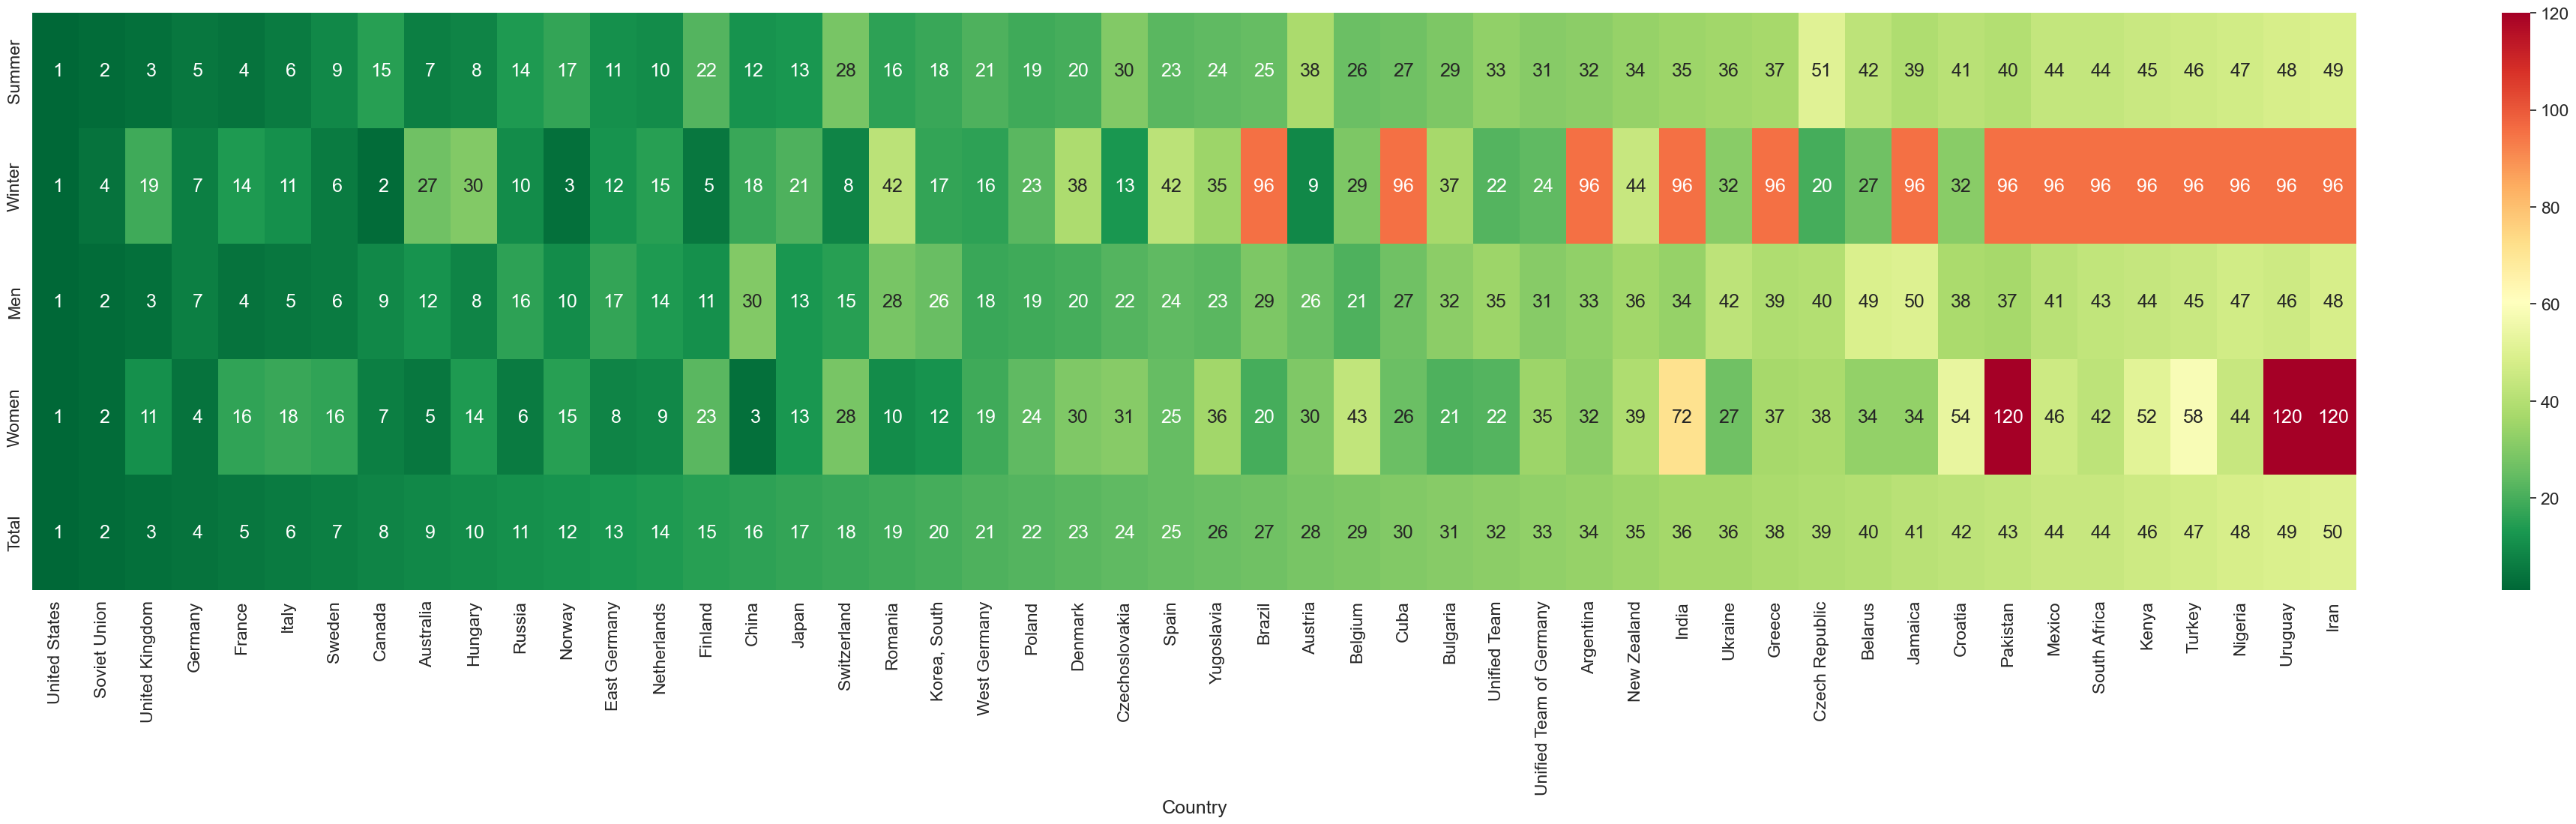

In [68]:
plt.figure(figsize= (50,10))
sns.heatmap(top_50.T, cmap = "RdYlGn_r", annot=True, fmt='2.0f')
plt.show()

In [69]:
top_50.sort_values("Summer")

,Summer,Winter,Men,Women,Total
Country,,,,,
United States,1.0,1.0,1.0,1.0,1.0
Soviet Union,2.0,4.0,2.0,2.0,2.0
United Kingdom,3.0,19.0,3.0,11.0,3.0
France,4.0,14.0,4.0,16.5,5.0
Germany,5.0,7.0,7.0,4.0,4.0
Italy,6.0,11.0,5.0,18.0,6.0
Australia,7.0,27.0,12.0,5.0,9.0
Hungary,8.0,30.0,8.0,14.0,10.0
Sweden,9.0,6.0,6.0,16.5,7.0


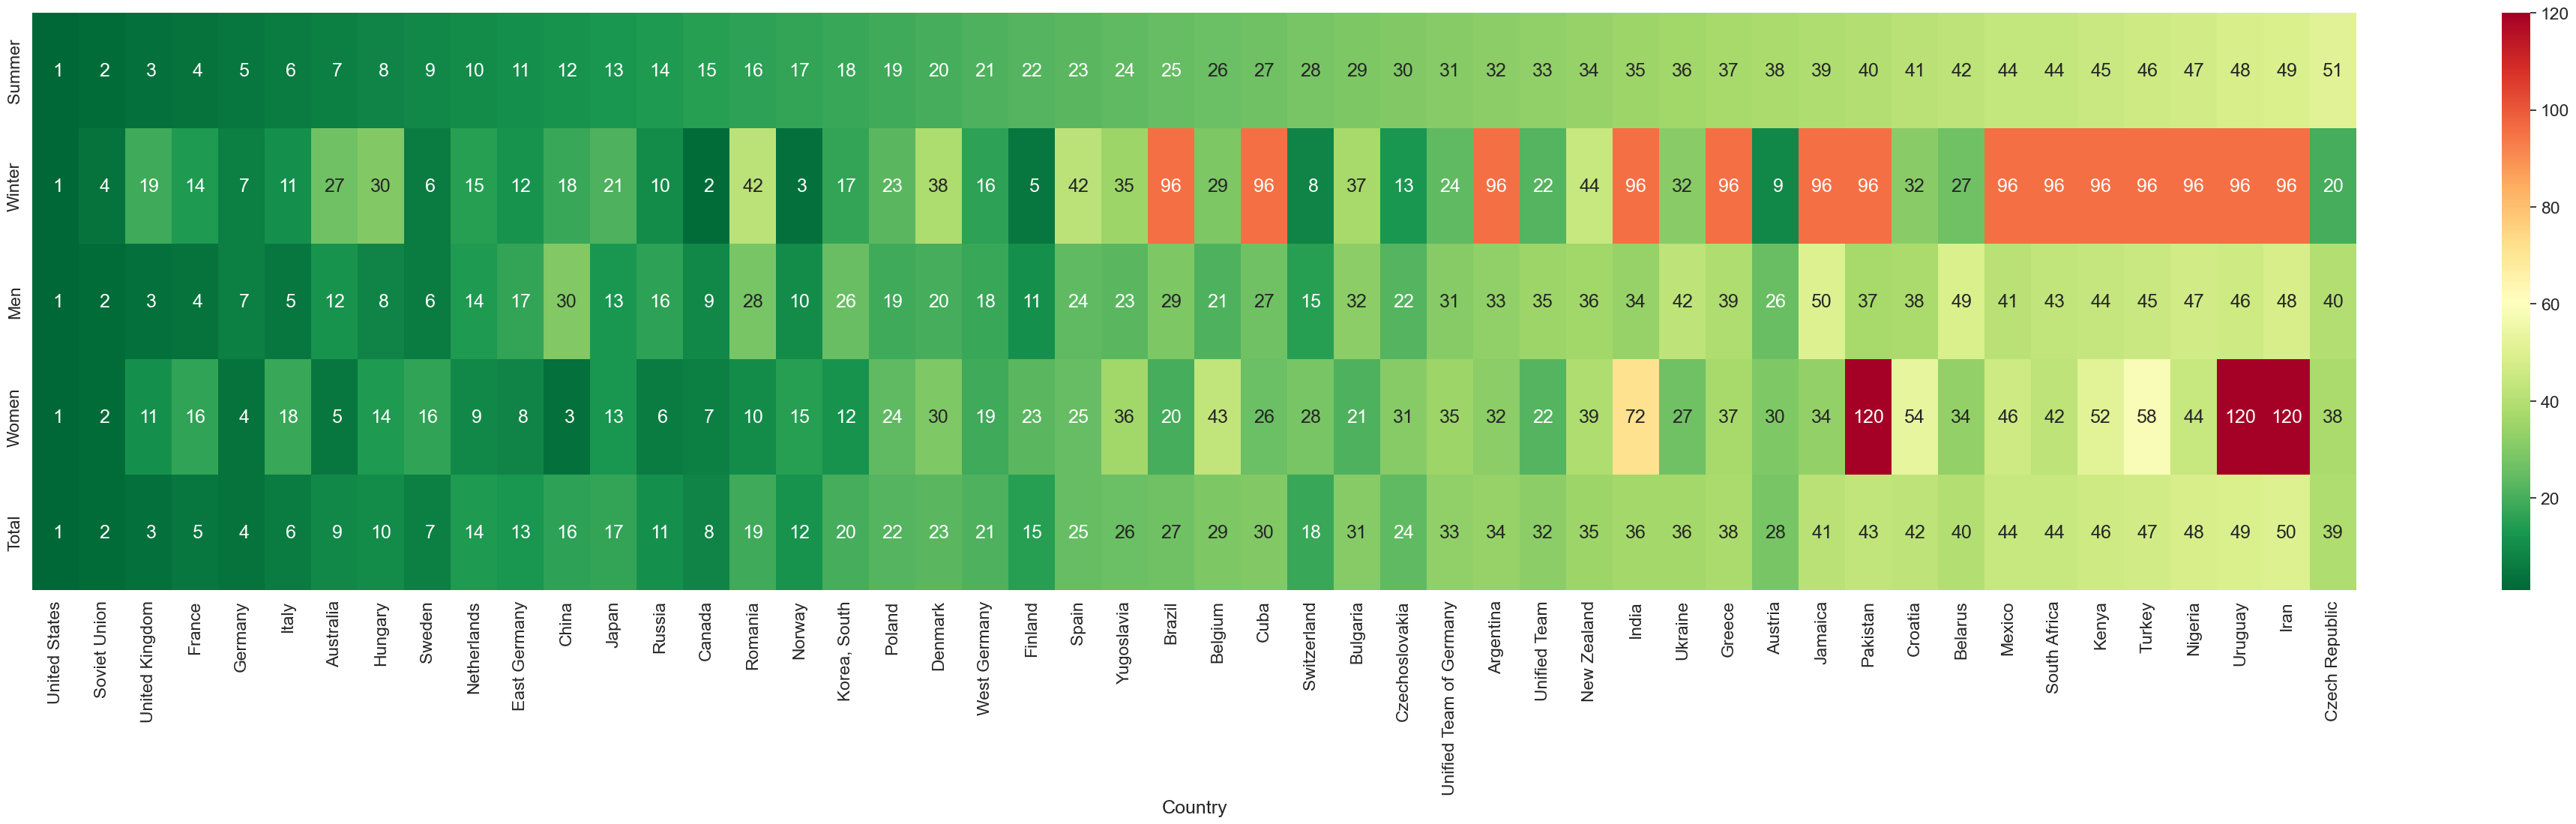

In [70]:
plt.figure(figsize =(50, 10))
sns.heatmap(top_50.sort_values(by = "Summer").T, cmap = "RdYlGn_r", annot=True, 
           fmt= '2.0f')
plt.show()

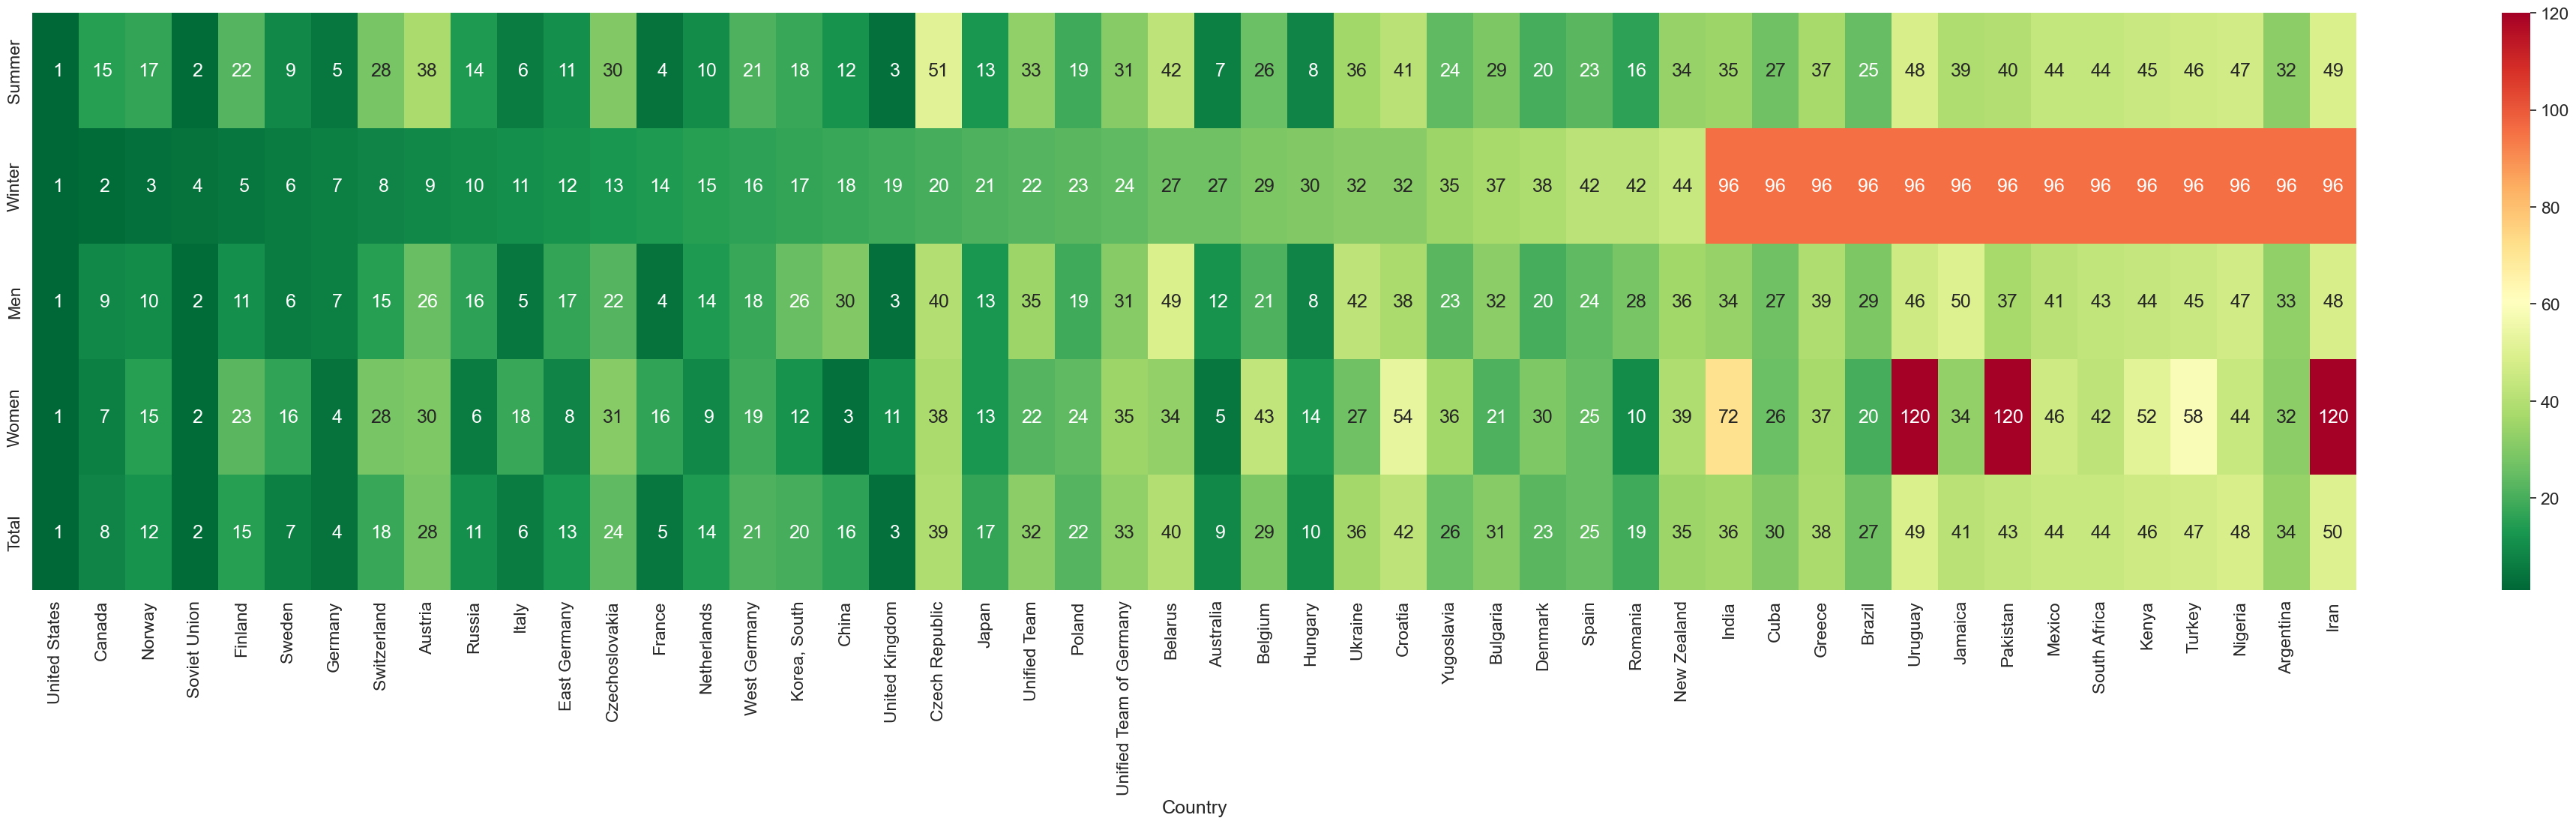

In [71]:
plt.figure(figsize =(50, 10))
sns.heatmap(top_50.sort_values(by = "Winter").T, cmap = "RdYlGn_r", annot=True, 
           fmt= '2.0f')
plt.show()

In [72]:
top_50["Summer"].sub(top_50["Winter"]).sort_values()

Country
Brazil                    -70.5
Cuba                      -68.5
Argentina                 -63.5
India                     -60.5
Greece                    -58.5
Jamaica                   -56.5
Pakistan                  -55.5
South Africa              -52.0
Mexico                    -52.0
Kenya                     -50.5
Turkey                    -49.5
Nigeria                   -48.5
Uruguay                   -47.5
Iran                      -46.5
Romania                   -25.5
Hungary                   -22.0
Australia                 -20.0
Denmark                   -18.5
Spain                     -18.5
United Kingdom            -16.0
Yugoslavia                -11.0
New Zealand               -10.5
France                    -10.0
Japan                      -8.0
Bulgaria                   -8.0
China                      -6.0
Netherlands                -5.0
Italy                      -5.0
Poland                     -4.0
Belgium                    -3.0
Soviet Union               -2.0


In [73]:
rank_diff = top_50["Summer"].sub(top_50["Winter"]).sort_values().to_frame()
rank_diff

,0
Country,
Brazil,-70.5
Cuba,-68.5
Argentina,-63.5
India,-60.5
Greece,-58.5
Jamaica,-56.5
Pakistan,-55.5
South Africa,-52.0
Mexico,-52.0


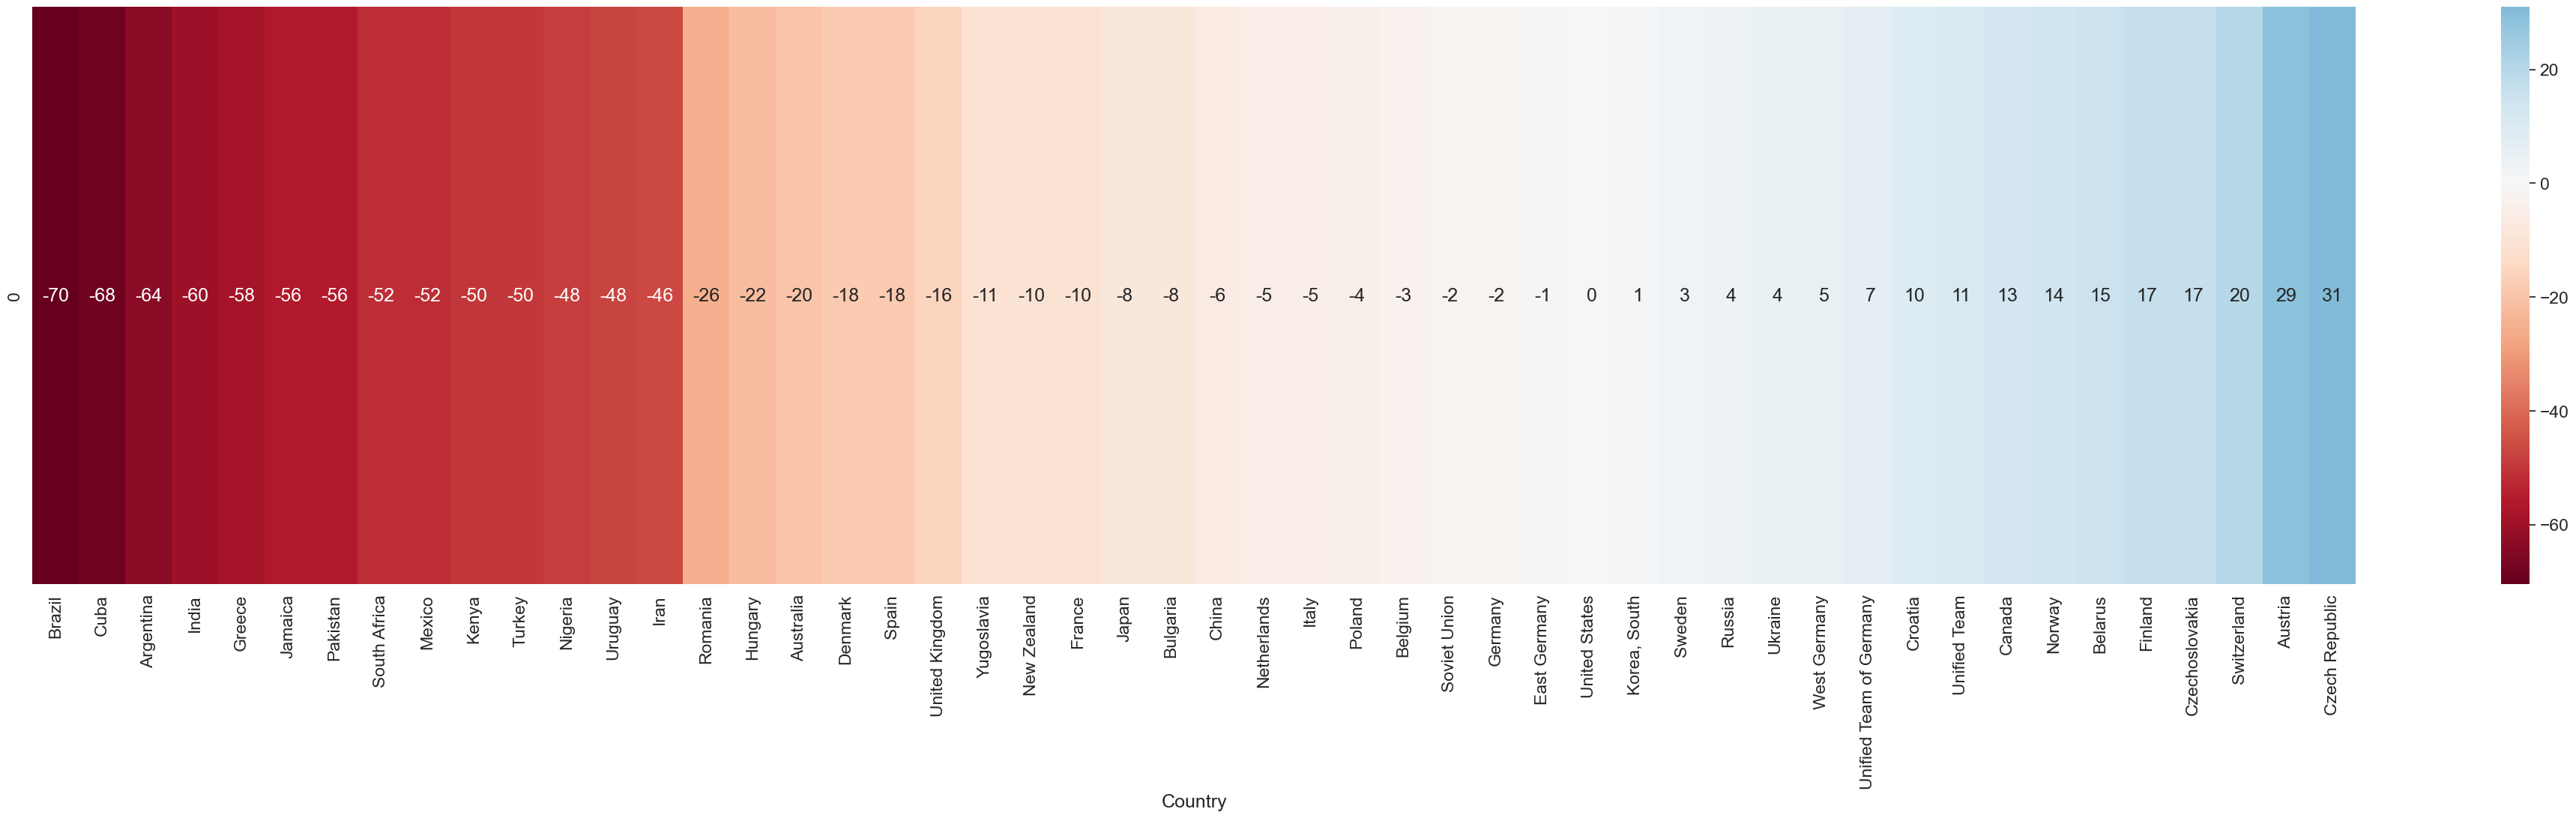

In [74]:
plt.figure(figsize =(50, 10))
sns.heatmap(rank_diff.T, cmap = "RdBu", annot=True, 
           fmt= '2.0f', center = 0)
plt.show()

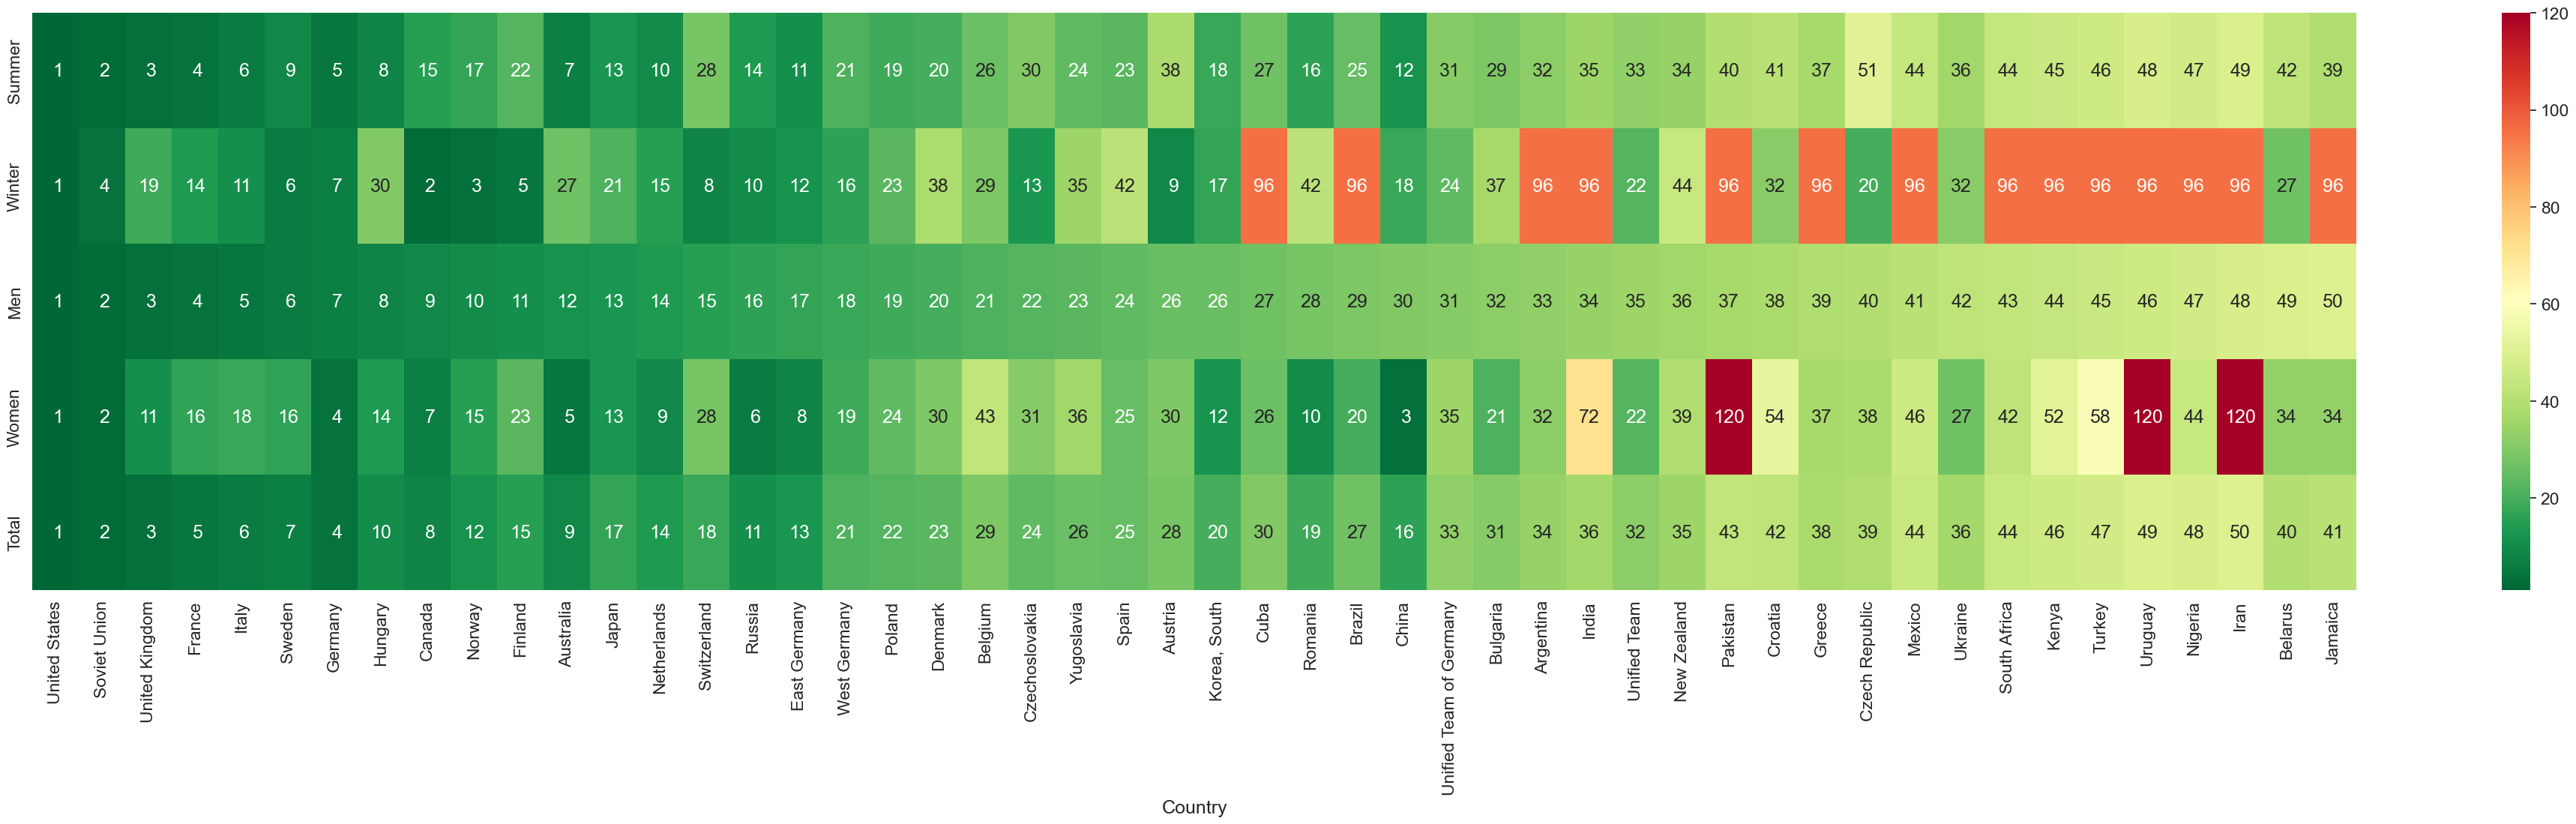

In [75]:
plt.figure(figsize =(50, 10))
sns.heatmap(top_50.sort_values(by = "Men").T, cmap = "RdYlGn_r", annot=True, 
           fmt= '2.0f')
plt.show()

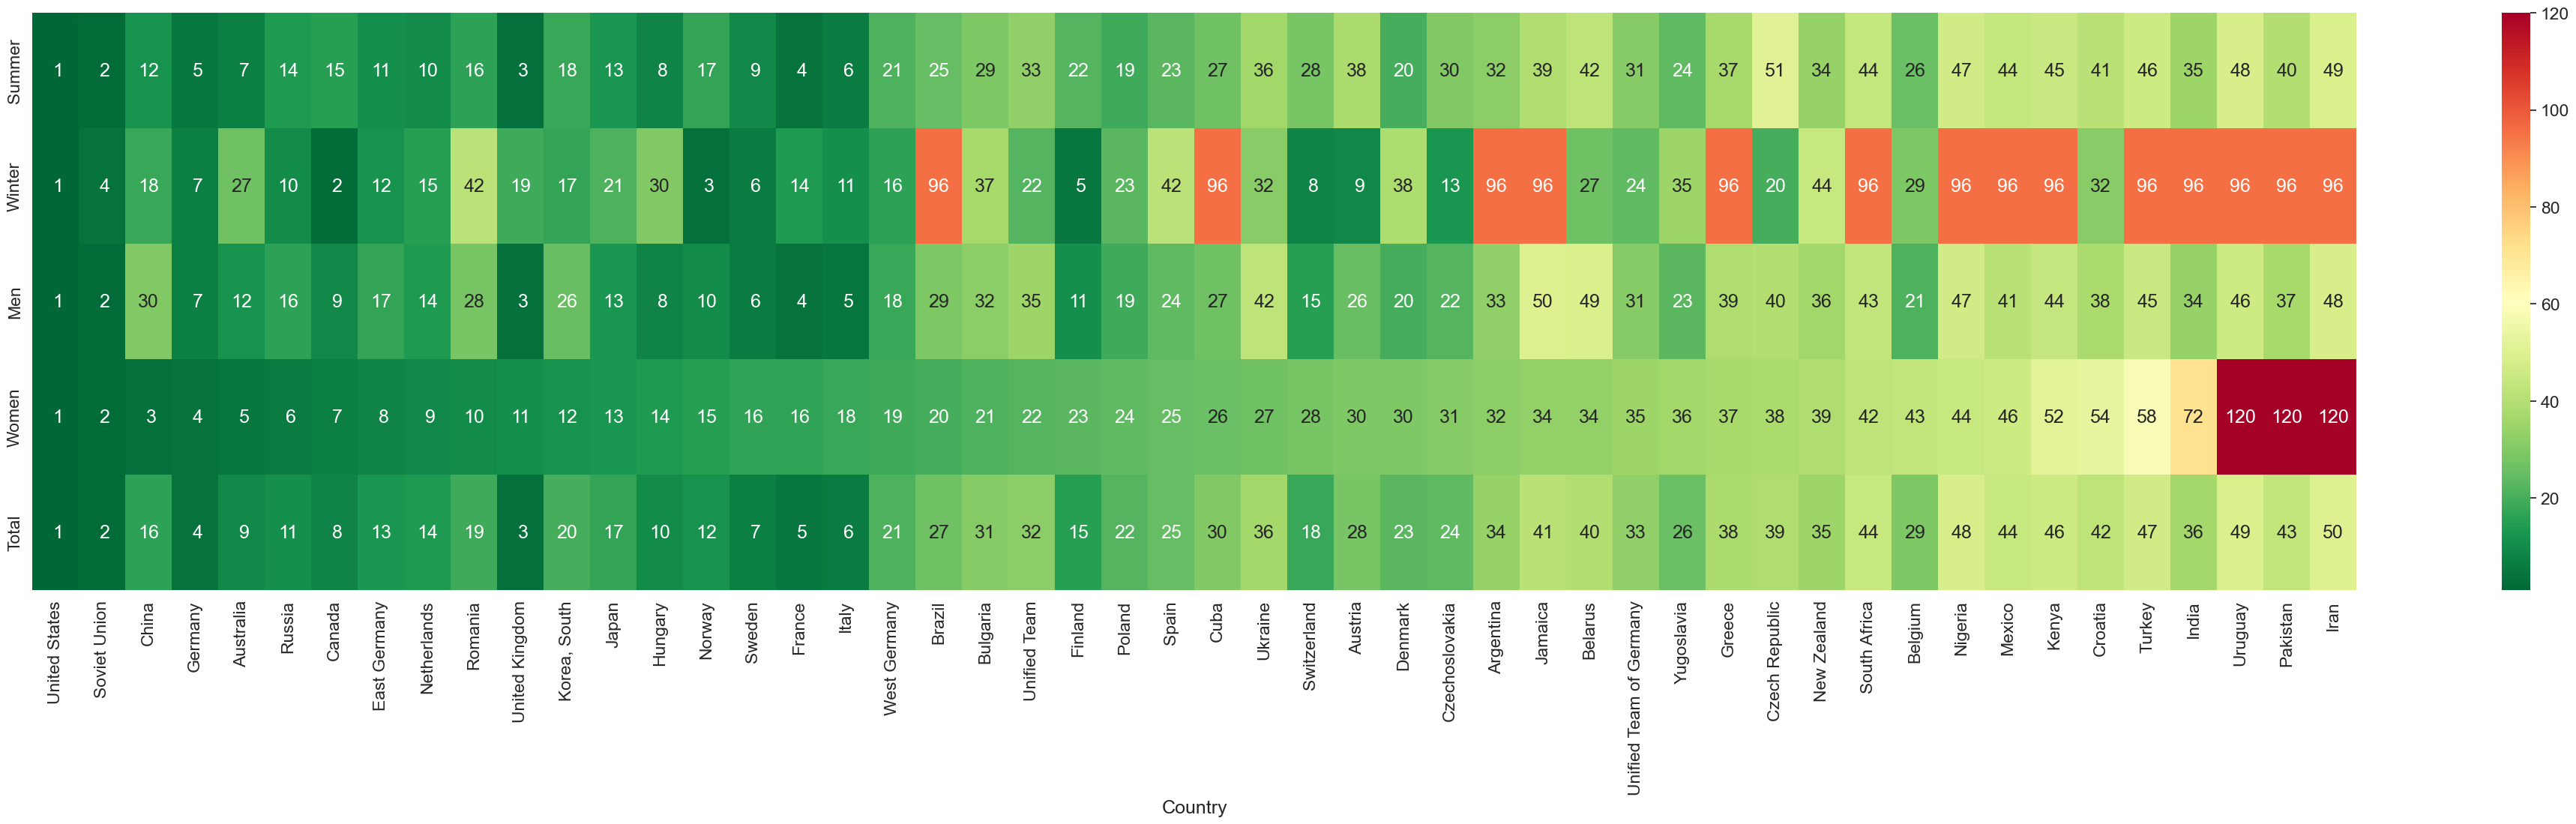

In [76]:
plt.figure(figsize =(50, 10))
sns.heatmap(top_50.sort_values(by = "Women").T, cmap = "RdYlGn_r", annot=True, 
           fmt= '2.0f')
plt.show()

In [77]:
rank_diff2 = top_50["Men"].sub(top_50["Women"]).sort_values().to_frame()
rank_diff2

,0
Country,
Pakistan,-83.0
Uruguay,-74.0
Iran,-72.0
India,-37.5
Belgium,-22.0
Croatia,-15.5
Turkey,-13.5
Yugoslavia,-13.0
Italy,-13.0


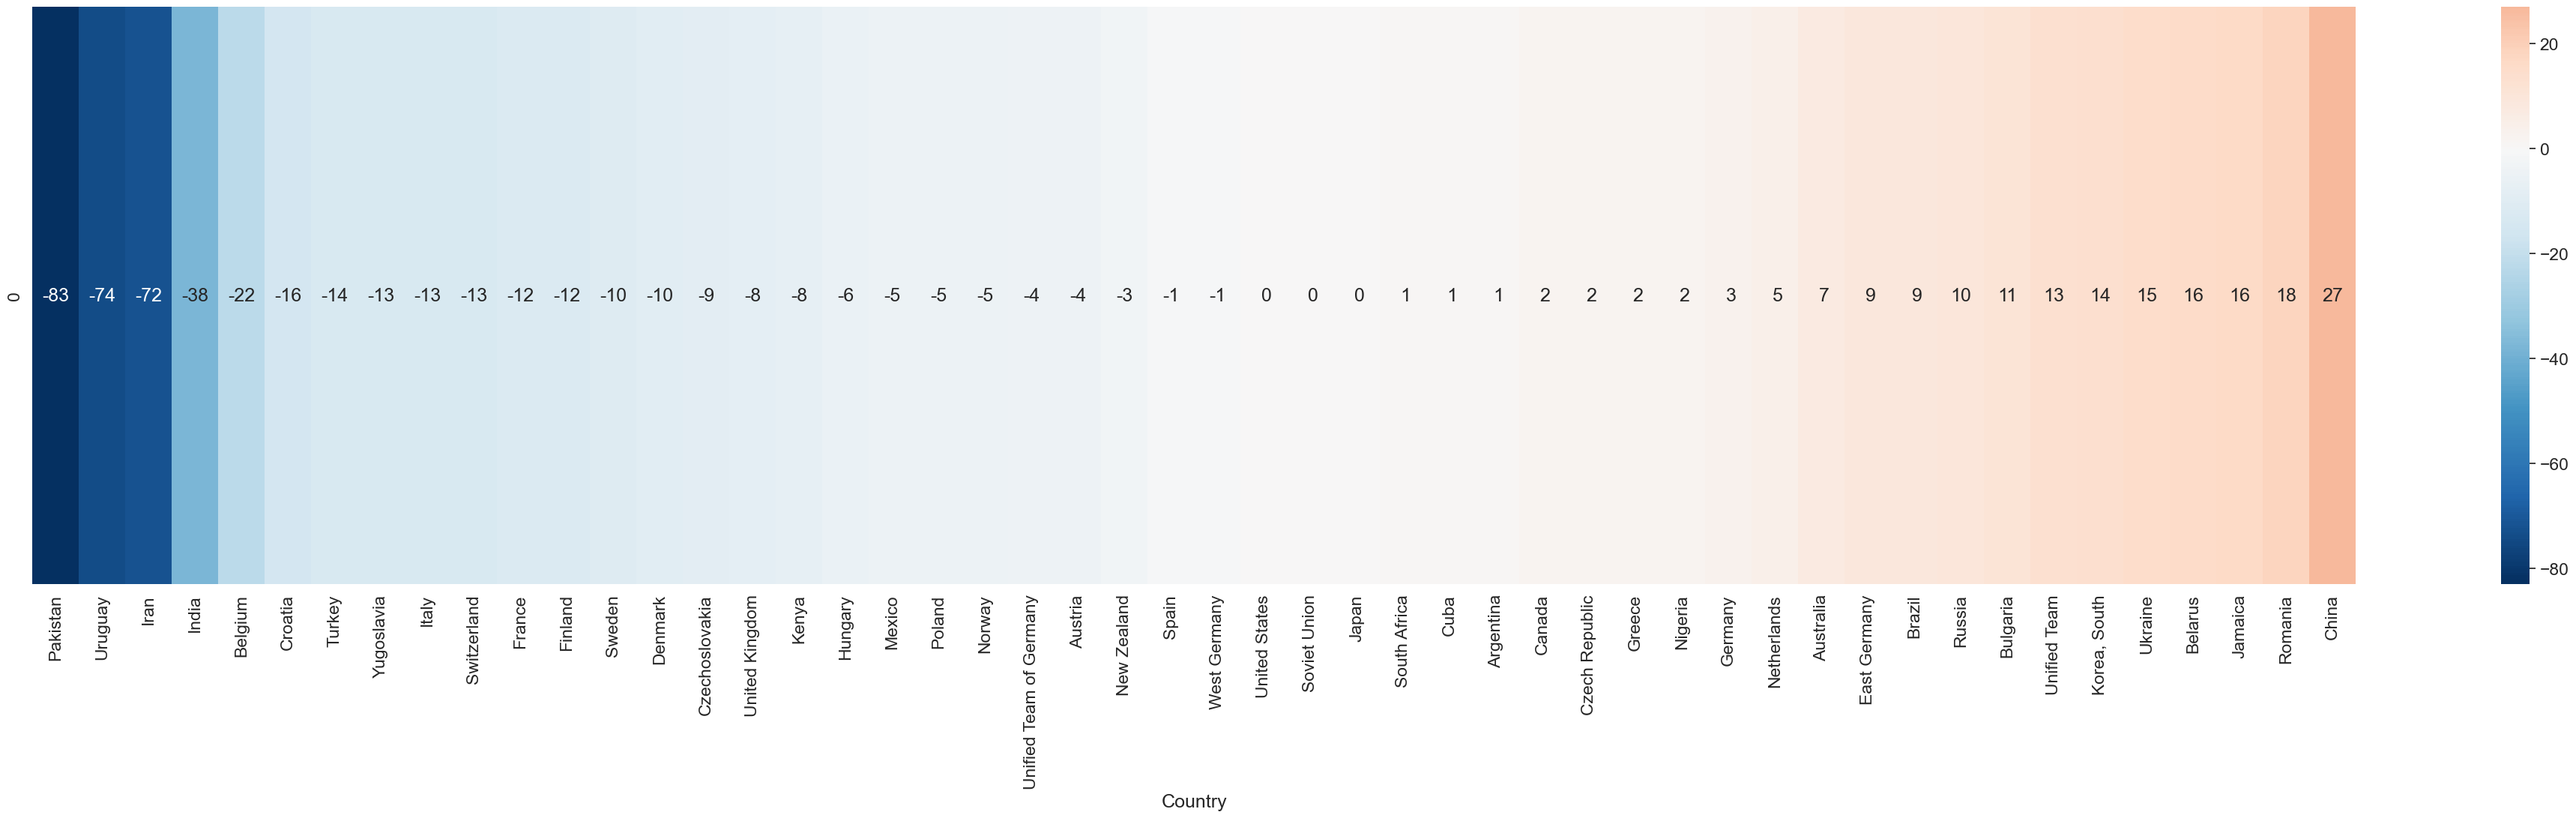

In [78]:
plt.figure(figsize =(50, 10))
sns.heatmap(rank_diff2.T, cmap = "RdBu_r", annot=True, 
           fmt= '2.0f', center = 0)
plt.show()

In [79]:
olympics["Sport"].value_counts()

Sport
Aquatics             4170
Athletics            3637
Rowing               2667
Gymnastics           2307
Skiing               1781
Fencing              1613
Ice Hockey           1563
Football             1497
Hockey               1422
Skating              1256
Wrestling            1211
Shooting             1150
Sailing              1109
Cycling              1105
Basketball           1012
Canoe / Kayak        1002
Volleyball            994
Handball              973
Equestrian            939
Boxing                894
Weightlifting         591
Judo                  491
Bobsleigh             452
Biathlon              420
Baseball              335
Archery               329
Tennis                296
Rugby                 192
Softball              180
Luge                  180
Modern Pentathlon     180
Curling               172
Badminton             144
Table Tennis          144
Taekwondo             112
Tug of War             94
Canoe                  81
Polo                   66
Lacros

In [80]:
sports = olympics["Sport"].value_counts().index
sports

Index(['Aquatics', 'Athletics', 'Rowing', 'Gymnastics', 'Skiing', 'Fencing',
       'Ice Hockey', 'Football', 'Hockey', 'Skating', 'Wrestling', 'Shooting',
       'Sailing', 'Cycling', 'Basketball', 'Canoe / Kayak', 'Volleyball',
       'Handball', 'Equestrian', 'Boxing', 'Weightlifting', 'Judo',
       'Bobsleigh', 'Biathlon', 'Baseball', 'Archery', 'Tennis', 'Rugby',
       'Softball', 'Luge', 'Modern Pentathlon', 'Curling', 'Badminton',
       'Table Tennis', 'Taekwondo', 'Tug of War', 'Canoe', 'Polo', 'Lacrosse',
       'Golf', 'Triathlon', 'Cricket', 'Rackets', 'Croquet',
       'Water Motorsports', 'Basque Pelota', 'Roque', 'Jeu de paume'],
      dtype='object', name='Sport')

In [81]:
top_20 = olympics["Country"].value_counts().head(20).index
top_20

Index(['United States', 'Soviet Union', 'United Kingdom', 'Germany', 'France',
       'Italy', 'Sweden', 'Canada', 'Australia', 'Hungary', 'Russia', 'Norway',
       'East Germany', 'Netherlands', 'Finland', 'China', 'Japan',
       'Switzerland', 'Romania', 'Korea, South'],
      dtype='object', name='Country')

In [82]:
by_sport = pd.crosstab(olympics.Country, olympics.Sport)
by_sport

Sport,Aquatics,Archery,Athletics,Badminton,Baseball,Basketball,Basque Pelota,Biathlon,Bobsleigh,Boxing,...,Softball,Table Tennis,Taekwondo,Tennis,Triathlon,Tug of War,Volleyball,Water Motorsports,Weightlifting,Wrestling
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,0,0
Algeria,0,0,7,0,0,0,0,0,0,6,...,0,0,0,0,0,0,0,0,0,0
Argentina,3,0,5,0,0,24,0,0,0,24,...,0,0,1,6,0,0,12,0,2,0
Armenia,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,4,6
Australasia,11,0,1,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
West Germany,62,0,67,0,0,0,0,14,22,6,...,0,0,0,3,0,0,0,0,7,9
West Indies Federation,0,0,5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Yugoslavia,91,0,2,0,0,96,0,0,0,11,...,0,4,0,0,0,0,24,0,0,16


In [83]:
by_sport = by_sport.rank(ascending = False, method = "average")
by_sport

Sport,Aquatics,Archery,Athletics,Badminton,Baseball,Basketball,Basque Pelota,Biathlon,Bobsleigh,Boxing,...,Softball,Table Tennis,Taekwondo,Tennis,Triathlon,Tug of War,Volleyball,Water Motorsports,Weightlifting,Wrestling
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,101.0,84.0,122.0,78.0,76.0,83.0,74.0,84.5,80.5,112.0,...,75.0,79.0,19.5,90.5,79.0,76.5,86.0,74.0,103.5,103.0
Algeria,101.0,84.0,47.0,78.0,76.0,83.0,74.0,84.5,80.5,35.0,...,75.0,79.0,89.5,90.5,79.0,76.5,86.0,74.0,103.5,103.0
Argentina,41.0,84.0,53.5,78.0,76.0,11.5,74.0,84.5,80.5,9.0,...,75.0,79.0,28.0,12.0,79.0,76.5,17.0,74.0,45.5,103.0
Armenia,101.0,84.0,122.0,78.0,76.0,83.0,74.0,84.5,80.5,70.5,...,75.0,79.0,89.5,90.5,79.0,76.5,86.0,74.0,35.5,40.0
Australasia,30.5,84.0,88.0,78.0,76.0,83.0,74.0,84.5,80.5,70.5,...,75.0,79.0,89.5,31.0,79.0,76.5,86.0,74.0,103.5,103.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
West Germany,18.0,84.0,16.0,78.0,76.0,83.0,74.0,9.0,6.5,35.0,...,75.0,79.0,89.5,21.0,79.0,76.5,86.0,74.0,28.5,32.0
West Indies Federation,101.0,84.0,53.5,78.0,76.0,83.0,74.0,84.5,80.5,112.0,...,75.0,79.0,89.5,90.5,79.0,76.5,86.0,74.0,103.5,103.0
Yugoslavia,16.0,84.0,70.0,78.0,76.0,3.0,74.0,84.5,80.5,25.5,...,75.0,5.5,89.5,90.5,79.0,76.5,12.0,74.0,103.5,20.0


In [84]:
by_sport = by_sport.loc[top_20, sports].copy()

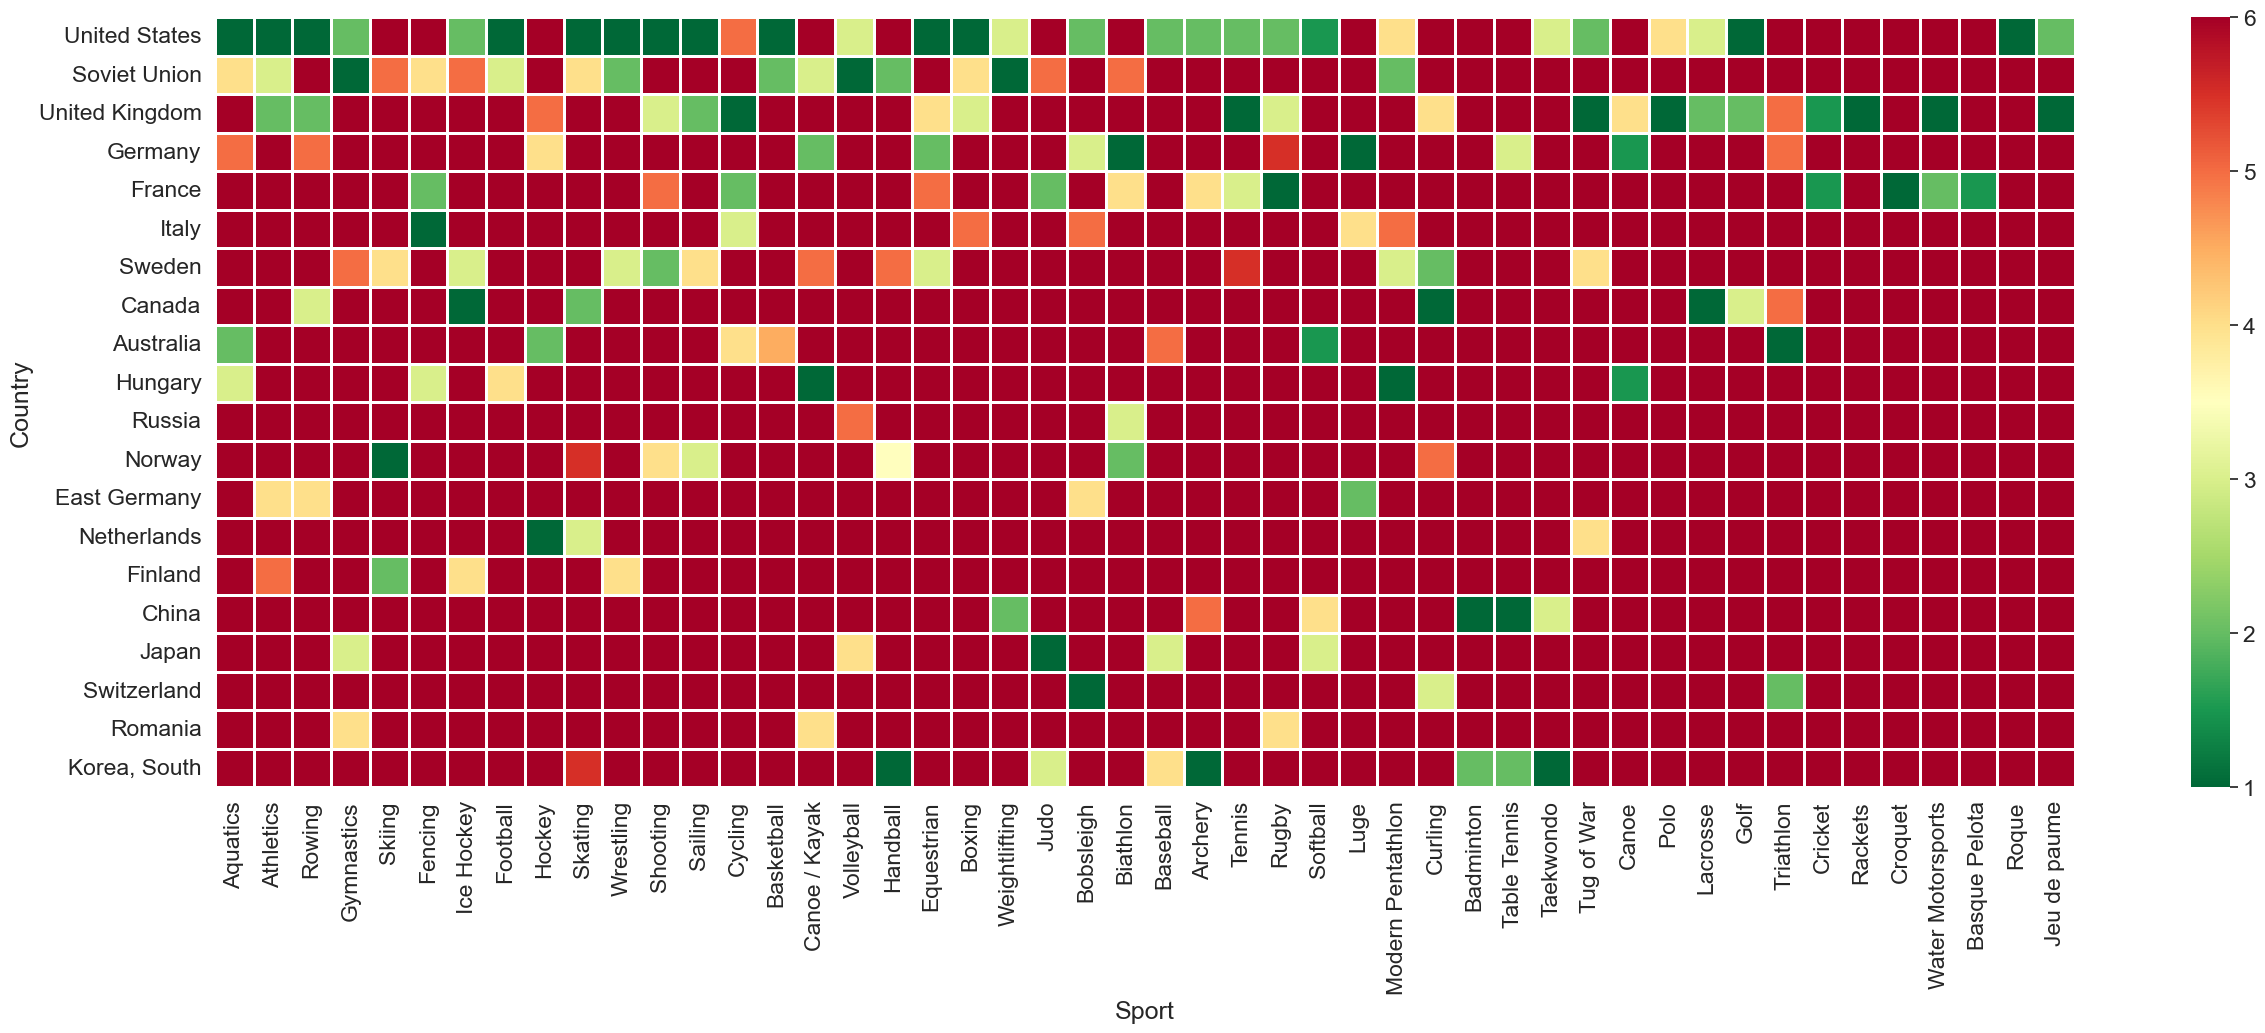

In [85]:
plt.figure(figsize = (30, 10))
sns.heatmap(by_sport,cmap='RdYlGn_r', vmin = 1, vmax = 6, linewidth = 1)
plt.show()